<a href="https://colab.research.google.com/github/tmckim/NS479_NeuroTechniquesLab/blob/main/SP26/EpilepsyCaseStudy_CellTypes_Notebook_03_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Epilepsy Case Study Notebook

## Investigating Questions of Interest Using the Allen Institute Cell Types Dataset

It's time to access the Allen Cell Types Database to do some analysis for Dr. Marsh's research 🧪  . Refer to the Case Study Document posted on Webcampus for details on how this dataset was collected and how to interpret it.

This notebook will help us investigate data collected from the [Cell Types](https://celltypes.brain-map.org/overview) dataset from the Allen Brain Institute.

**<font color="red" size=4> IMPORTANT: This notebook is READ-ONLY. To edit and run this notebook, follow the steps below.</font>**

---
<a name="save"></a>
## Before you start - Save this notebook! 💾

When you open a new Colab notebook from the WebCampus (like you hopefully did for this one), you cannot save changes. So it's  best to store the Colab notebook in your personal drive `"File > Save a copy in drive..."` **before** you do anything else.

The file will open in a new tab in your web browser, and it is automatically named something like: "**Copy of EpilepsyCaseStudy_CellTypes_Notebook.ipynb**". <br>You can rename this to just the title of the assignment "**EpilepsyCaseStudy_CellTypes_Notebook.<br>ipynb**". Make sure you do keep an informative name (like the name of the assignment) so that you know which files to submit back to WebCampus for grading! More instructions on this are at the end of the notebook.


___

**Where does the notebook get saved in Google Drive?**

By default, the notebook will be copied to a folder called “Colab Notebooks” at the root (home directory) of your Google Drive. If you use this for other courses or personal code notebooks, I recommend creating a folder for this course and then moving the assignments AFTER you have completed them.


____
# Learning Objectives 🙋
<a name="LOs"></a>
## At the end of this assignment, you'll be able to:
* Analyze electrophysiological data from human epileptic patients
    * Experimental data was collected from living human brain tissue from the Allen Institute 🧠 🧬
    * Apply big data from high-throughput experiments to detect patterns and quantify data 🔎 📈
* Apply appropriate statistics to quantitative results 💻
* Describe practical considerations of data collection in humans 🖊 💭
* Interpret basic science data in the context of pre-translational research ⚛ ⚕


______

# Survey 📌

Please fill out the pre-session survey (anonymous):

---
<a name="import-setup"></a>
# 1.0 Setup, import, and load files needed 🧰 🛠


There are several steps we need to do to access the dataset before we can load the file:
1. Mount our google drive (gdrive) so we can save figures from the session today
2. Copy the data file to working memory to run in this notebook
3. Check that we have it available to us<br>


## 1.1 Setup
<a name="setup"></a>

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cells step-by-step below to setup the notebook - connect to google drive and make a folder to save figures generated during class.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Step 1
# Setup and add files needed to access gdrive
from google.colab import drive                                   # these lines mount your gdrive to access the files we import below
drive.mount('/content/gdrive', force_remount=True)

In [ ]:
### RUN THIS CELL ###

# Step 2: Setup a folder in gdrive to save the figures

import os

# ====== OPTIONAL: EDIT THIS ONE LINE ONLY ======
folder_name = "NeuroCodingWorkshop_EpilepsyCaseStudy_Materials"

base_path = "/content/gdrive/MyDrive"
save_path = os.path.join(base_path, folder_name)

# check if folder already exists; if not, make it
if os.path.isdir(save_path):
    print("Given directory exists")
else:
    print("Given directory doesn't exist, making it")
    os.makedirs(save_path, exist_ok=True)

print(f"Figures from today's session will be saved in Google Drive folder called: {folder_name}")

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style="font-size: 20px;" class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
  We will start by downloading the data file (<code>Allen_celltypes_specimen_alldata_downloaded_11102023.csv</code>) to access for today.<br>
  Run the cell below. If it works, you should see text that looks like this:
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Step 3
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1ipezOh7wcELtl415Bvg__wFGEx5a41me' -O Allen_celltypes_specimen_alldata_downloaded_11102023.csv

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style="font-size: 20px;" class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
  On the left side of the Colab window, click the 📁 icon. You can go to gdrive and the folder for today's session:
  <b>NeuroCodingWorkshop_EpilepsyCaseStudy_Materials</b>
  <br><br>
  You should see a file called <code> Allen_celltypes_specimen_alldata_downloaded_11102023.csv </code>.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
#@title Alert
from IPython.display import HTML

alert_info = '''
<div class="alert alert-block alert-warning">
<div style= "font-size: 20px">
  <h4 class="alert-heading">Alert</h4>
<b>If this was not successful for you, please let us know and we will help troubleshoot!</b>
</div>
'''


display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

---
<a name="import-packages"></a>
## 1.2 Import packages needed

For this Colab notebook we will be working with 5 packages that typically come pre-installed on most versions of Python. They are:

- **[numpy](https://numpy.org/doc/stable/user/index.html)**: A library for working with numerical lists, called arrays
- **[pandas](https://pandas.pydata.org/docs/user_guide/index.html)**: A library for working with two dimenional lists, called dataframes
- **[matplotlib](https://matplotlib.org/stable/tutorials/index)**: A package for plotting, commonly used in tandem with numpy and pandas
- **[seaborn](https://seaborn.pydata.org/tutorial.html)**: A package for plotting, commonly used in tandem with pandas
- **[scipy](https://docs.scipy.org/doc/scipy/)**: A package for scientific computing (analysis) in python

</br><img src="https://miro.medium.com/max/765/1*cyXCE-JcBelTyrK-58w6_Q.png" width=200> <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1200px-Pandas_logo.svg.png" width=200> </br><img src="https://matplotlib.org/stable/_static/logo_dark.svg" width=200> <img src="https://seaborn.pydata.org/_images/logo-wide-lightbg.svg" width=200><br>
<img src="https://miro.medium.com/v2/resize:fit:672/0*ojdu3YHkpKVBMWgP.png" width=150>
</br></br>
We can import these libraries (or certain classes/functions from these libraries) into our local runtime using the following code. The nicknames I used (`np`, `plt`, `np`, and `sns`) are pretty standard nicknames that most Python programmers use, though you could use anything.



In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
 Make sure our needed packages are installed in our coding environment by running the code below. For example, when you see <code>np</code> in our script, it's actually calling scripts from the <code>numpy</code> package.
 </div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Import our plotting package from matplotlib and shorten it to plt
import matplotlib.pyplot as plt

# Specify that all plots will happen inline & in high resolution
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Import pandas for working with databases and shorten it to pd
import pandas as pd

# Import numpy and shorten it to np
import numpy as np

# Import stats from scipy and shorten it to stats
from scipy import stats

# Import plotting package seaborn and shorten to sns
import seaborn as sns

# Print statement to confirm
print('Packages imported!')

---
<a name="restart-notebook"></a>
## 1.3 Restarting your notebook 📔



If your kernel stops working, or you close your notebook and come back to it: you  need to run the above cells ^^ and also the cell below (load the datafile) to make sure it will work properly.<br>

This includes:

1.   [Setup steps](#import-setup) (cells above)
2.   [Importing packages](#import-packages) (cell above)
3.   [Loading in the data file](#load)
     * You can start from the beginning again and reload everything <br>
     OR <br>
     * If you've already completed up to the [Restarting: load organized data](#restart), you can skip the data cleaning/organizing steps (if you've already completed them) and jump to that section to start analyses.

---
<a name="load"></a>
## 1.4 Load in the data file ⌛

The data was directly downloaded from the Allen Institute website to a csv file. It was copied to your google drive folder upon import at the beginning. This way we can easily import the data we want to work with.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below to import the data using the <code>pandas</code> package (which we shortened to <code>pd</code> when we imported it).
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

## Import file
all_data = pd.read_csv('Allen_celltypes_specimen_alldata_downloaded_11102023.csv')
print('data imported!')

---
<a name="view-data"></a>
# 2.0 Viewing the Data 👀

Notice that when you write an assignment statement like the one above, python doesn't automatically print anything out or show you the dataset in this case.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
To show the data, run the cell below where we have typed out the name of the variable that contains our dataset.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Show the dataset
all_data

### DataFrames
<a name="dataframes"></a>


The dataset above looks like it is in a format you may be familiar with, a table. However, we used the package `pandas` to import our data, so it is actually in a format called a `dataframe`. This is a fancy name for a table that allows you to flexibly work with large amounts of data.

<a name="dataframe-index"></a>
### DataFrame Index

Notice how there is an extra column of numbers in the DataFrame that results. This first column contains numbers that are called the index of a DataFrame, and are useful if you need to select different rows from that data that you might be interested in. <br>

More info can be found here on the [index](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.index.html) and [dataframes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)

<a name="dataframe-vs-series"></a>
### DataFrames versus Series

In `pandas`, we have two types of objects: DataFrames and Series. Series are similar to a DataFrame except there is only one column in a Series. You can think of Series as a single column of a DataFrame. <br><br>

You can learn more about DataFrames and Series with this [documentation](https://pandas.pydata.org/pandas-docs/stable/dsintro.html) as well.

---
<a name="preview"></a>
## 2.1 Preview the data and columns

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below to preview the data.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Another thing to do when you first look at your new data, is to see what info is there
# This is possible with .info() after the name of your data frame like so:
all_data.info()

We have 2333 rows (observations) and 54 columns! <br> In the column labeled `Column`, the names of each column are listed and it shows how many non-null values are present, meaning how much data there is. Any difference between this number and the total number of entries (2333 shown at the top) indicates there is missing data. <br>
The last column `Dtype` tells us what type of data you have in each column. You can see here that many are numbers and have no decimals (`int`) or have decimal values (`float64`). Note that in `pandas`, strings are labeled as `object` (first entry). <br> <br>
We can see that we do have missing data here. Particularly note that the columns that start with `donor__` have the lowest number of values, with only 413 cells to work with 🧑 . The other data in the table comes from a different species and is data from mice 🐭 - there is alot more data available. <br><br>
If you go back up and review the table, you will see that missing values are labeled with `NaN`, which stands for `Not a Number`. This is typically a common naming convention to use, and you will see it across datasets.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below to preview only the column names.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Let's take a peek at column names
list(all_data)                # if you want a nicely aligned column in the order the cols appear in dataframe

In [ ]:
 # np.sort(list(all_data))     # uncomment this line if you want to see them sorted alphabetically instead

### 2.1.1 Formatting the dataframe - many options!

In [ ]:
### RUN THIS CELL ###

pd.options.display.float_format = '{:.1f}'.format  # don't use scientific notation

---
<a name="data-avail"></a>
## 2.2 Data Column Details:
Info is available in a document [here](https://docs.google.com/document/d/1mkthEWVFahcUK5arfEhr0oEOBWQ0sppi/edit?usp=sharing&ouid=103007457495122301197&rtpof=true&sd=true)

*   The `line_name` indicates the cell types that were labeled with Cre-recombinase (genetic manipulation, only in mice)
*   The `specimen_id` which is a unique identifier (note that an individual can contribute multiple cells; if that's the case, the same `specimen_id` is different across rows, but `donor__id` is the same)
*   The `specimen_name` is a unique identifier
    * human cells start with 'H'
    * each id is unique, but `donor__id` is the same
*   The `specimen_hemisphere` indicates whether the sample is from the right or left side of the brain
*   The `structure_id` is a unique number for the brain structure
*   The `structure_name` is a string containing the full name of the brain region
*  The `structure_acronym` is a text abbreviation for the brain region
*  The `structure_parent_id` is a more general number that codes the overall brain region (not layer specific)
*  The `structure_parent_acronym` is a text abbreviation without cortical layer info
*  The `structure_layer` indicates the cortical layer of the brain

### Morphological features
*  The `nr__max_euclidean_distance` is the max euclidean distance of a branch and its path length (mircometers)
*  The `nr__number_stems` is the number of processes attached to the soma
*  The `nr__number_bifurcations` is the number of points where a process splits into two daughter processes
*  The `nr__average_contraction` is the average ratio between Euclidean distance of a branch and its path length
*  The `nr__average_parent_daughter_ratio` is the average ratio between the diameter of a daughter branch and its parent branch
*  The `nr__reconstruction_type` indicates full or dendrite only, if applicable (empty if N/A)
*  The `nrwkf_id` is an id for something, unclear based on documentation
*  The `erwkf_id` is an id for something, unclear based on documentation

### Electrophysiological features (ef)

*  The `ef__fast_trough_v_long_square` is the minimum value of the membrane potential in the interval lasting 5 ms after the peak
*  The `ef__upstroke_downstroke_ratio_long_square` is the ratio between the absolute values of the action potential peak upstroke and the action potential peak downstroke
*  The `ef__adaptation` is the rate at which firing speeds up or slows down during a stimulus
*  The `ef__f_i_curve_slope` is the slope of the curve between firing rate (f) and current injected (i)
*  The `ef__threshold_i_long_square` is the  current (pA) to elicit an action potential (threshold) when 1 s long square current injected
*  The `ef__tau` is the time constant of the membrane in milliseconds
*  The `ef__avg_isi` is the mean value of all interspike intervals in a sweep
*  The `ef__avg_firing_rate` is the average firing rate (spikes/s)
*  The `ef__ri` is the input resistance (milliohms)
*  The `ef__peak_t_ramp` is the timestamp of the maximum value of the membrane potential during the action potential (i.e. between the action potential's threshold and the time of the next action potential, or the end response) in response to a ramp stimulus
*  The `ef__vrest` is the resting membrane potential in mV

### Morphological features (even more)
*  The `si__height` is a measurement of somesort (unclear based on documentation)
*  The `si__width` is a measurement of somesort (unclear based on documentation)
*  The `si__path` is a file path to specimen details (unlikely relevant for us)
*  The `csl__x` is the 3D compartment position (x) for morphology reconstructions
*  The `csl__y` is the 3D compartment position (y) for morphology reconstructions
*  The `csl__z` is the 3D compartment position (z) for morphology reconstructions
*  The `csl__normalized_depth` is the depth of the cell soma normalized between pia (0) and white matter (1)


*  The `cell_reporter_status` is the expression of the reporter (mouse only- positive or negative)
*  The `m__glif` indicates there is a generalized leaky integrate-and-fire (glif) model for the cell (number indicates type, 0 indicates none)
*  The `m__biophys`indicates the existence of a biophysical model for the cell  (0 indicates none)
*  The `m__biophys_perisomatic` indicates the existence of a perisomatic biophysical model for the cell  (0 indicates none)
*  The `m__biophys_all_active` indicates the existence of an all-active biophysical model for the cell (0 indicates none)
*  The `tag__apical` indicates the extent of apical dendrite preservation (intact or truncated), if applicable (N/A)
*  The `tag__dendrite_type` indicates the type of the dendritic spines: spiny, aspiny, or sparsely spiny
*  The `morph_thumb_path` is a file path to specimen details (unlikely relevant for us)
*  The `ehpys_thumb_path` is a file path to specimen details (unlikely relevant for us)
*  The `ephys_inst_thresh_thumb_path`is a file path to specimen details (unlikely relevant for us)

### Donor Characteristics
*  The `donor__age` is the age in years
*  The `donor__sex` indicates biological sex ♂ ♀
*  The `donor__disease_state` indicates disease state for human tissue: tumor or epilepsy
*  The `donor__race` indicates race/ethnicity of human donor
*  The `donor__years_of_seizure_history` indicates the length of seizure history (0 indicates none)
*  The `donor__species` indicates the species: mouse (mus musculus) 🐭 or human (homo sapiens) 🧑
*  The `donor__id` is a unique ID given to the individual (goes along with `donor__name`)
*  The `donor__name` is a unique ID for each individual (shortened name from beginning of `specimen id`)

---
<a name="view-cols"></a>
## 2.3 Viewing 😎 all columns in the dataframe

You have probably noticed that there are more columns listed above than what was shown to you in the original dataframe. In the output, you will see three ellipses (...) to indicate that columns were skipped in showing you the data to view. If you want to adjust this setting, you can do that with the following formatting code. Whether you want to do this is up to you and personal preference. You can also give it a try and see if you think it makes it harder for you to view the data that you want. If so, there is a cell below that you can run at anytime after you have changed the formatting to reset it back to a collapsed view.<br>

Warning ❗If you try to show all **rows**, the dataset is large and it might take several seconds to display it to you each time. I would recommend only showing all **columns** instead. <br>

If you are interested in more info, the documentation can be found [here](https://pandas.pydata.org/docs/user_guide/options.html).

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below if you want to expand the dataframe and show all columns.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### OPTIONAL: RUN THIS CELL ###

# We want to see all the columns in the dataset
pd.set_option('display.max_columns', None)

# pd.set_option('display.max_rows', None) # feel free to test this out, but it will take several seconds

In [ ]:
### RUN THIS CELL TO NOW SEE ALL COLUMNS ###

all_data

In [ ]:
#@title Task (Optional)
from IPython.display import HTML

alert_info = '''
<div class="alert alert-block alert-warning">
<div style= "font-size: 20px">
  <h4 class="alert-heading">Task (Optional)</h4>
Run the cell below if you want to reset to default options, or change the numbers to whatever you'd like!
</div>
'''


display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### OPTIONAL: RUN THIS CELL ###
# If that's too many rows, you can always reset back to the default (~10)

# Optional:
pd.reset_option('display.max_rows')

# Optional:
pd.set_option('display.max_rows', 20)     # Choose your own number!

---
<a name="select-cols"></a>
# 3.0 Selecting Columns

We can select a column or multiple columns, based on what information we want from the data. This allows us to pull out information that we want, in case we don't want to look at the data from the entire table. In `pandas` we use indexing with brackets `[]`.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the code below to select one column and return a series.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# select one column - return Series

all_data['donor__species']

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the code below and notice how it is different from above. It does the same thing though by selecting one column and returing it as a series (output is the same).
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# select one column - return Series

all_data.donor__species

Notice that you just got the same output using two different ways to access the column ( `[]` versus `.` indexing). Figuring out when to use it depends on different factors, and we won't go into those today. I encourage you to play around test out the different ways as you like in the notebook.

More info can be found on these websites:

https://www.dataschool.io/pandas-dot-notation-vs-brackets/ <br>
https://www.dunderdata.com/blog/use-the-brackets-to-select-a-single-pandas-dataframe-column-and-not-dot-notation <br>
https://pandas.pydata.org/pandas-docs/version/1.0/getting_started/intro_tutorials/03_subset_data.html <br>

There is also another way to access the data in the columns and return a dataframe.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the code below to select one column and return a dataframe.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# select one column - return DataFrame

all_data[['donor__species']]

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the code below to select multiple columns and return a dataframe.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# select multiple columns - return DataFrame

all_data[["donor__species", "donor__age"]]

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
If you want to view all columns in your dataframe in <code>pandas</code> you can also use the following method. <br>
Run the code below to view all column names.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# viewing all columns
all_data.columns

---
<a name="unique"></a>
## 3.1 `Unique` to find information in our columns of interest 🔬

One way to start examining our data is to see what values appear in the columns. Luckily, we don't have to do this by eye 👀 and scroll the whole way through the table (although I do recommend doing this to get a feel for the data!). <br><br>
We can use the function `unique` in `pandas` to help us out. It will return the unique values from the column we specify based on the order of appearance (it does not sort them in any way).<br> <br>

Helpful info can be found in the [pandas documentation](https://pandas.pydata.org/docs/reference/api/pandas.unique.html) and [elsewhere](https://favtutor.com/blogs/pandas-unique-values-in-column).

Below, we will first call the name of our dataframe (`all_data`) then reference the column name (`.<insert_column_name_here>`) and finally use `.unique()` to figure out the possible values in our column

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Which column do you think has the info about humans versus mouse data? <br>
Fill this in the code below where it says <code>&ltinsert_column_name_here&gt</code><br><br>

<i>Hint</i>: Look back at the dataframe (table) and check out what values are in each column.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS
# Use unique to show the categories and information we need in the next step

all_data.<insert_column_name_here>.unique()

In [ ]:
# @title Solution
# Use unique to show the categories and information we need in the next step
all_data.donor__species.unique()

---
<a name="filter"></a>
## 3.2 Filtering or Subsetting Data

We learned above how to pull out data from an entire column (or columns). Now, we want to pull out data from rows (across multiple columns) that meets a certain condition. The logic is similar, but we need to add a bit more to our code.<br> <br>
Remember that our data is similar within a column, but each row contains a mix of data across the columns. For example, some values are text (strings) and some are numbers. <br><br>
To filter a DataFrame based on the contents by rows in `pandas`, we need to use boolean (`True` or `False`) expressions in order to select the rows we want to keep. Conditional expressions (`>`,`<`, `==`, `!=`, `<=`, ...) enable us to test whether our conditions of interest would evaluate to `True` or `False`. Typically, we want to keep data in our rows that meets a certain criteria (`True`). Let's walk through an example.

We want to find only the **human** data, and our dataset has both data from mice 🐭 and humans 🧑 . <br>So to pull out only human data, we need to find a column that will allow us to identify which species we are working with. We actually did that above when we used `unique`. <br> We will use the same column, but now ask python to help us find the rows where data in that column meets the condition that the data is from a human.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Get human data only
human_data = all_data['donor__species'] == 'Homo Sapiens'
human_data

We put in the name of our column `donor__species` and asked python to find where this is equal to (`==`) `Homo Sapiens` 🧑 .<br>
You can see from the output that sometimes values in this column are `True`, meaning this corresponds to a row that contains human data. If you see `False`, this indicates that the value in the row did *NOT* meet our condition (equal to human), and is thus data from a mouse 🐭 .<br>
This is helpful to illustrate the values we would see if we only look at the column we specified `donor__species`.

We want to take this a step further, because we don't want to work with just one column in our dataset! It's important to see what python is doing and how it interprets the code, since this is an intermediate step in the code we will run below.<br>
We want to use the code we've written above but now apply this **filtering across the entire dataset**. So, we want to pull out all rows where data came from humans, and also keep all columns in our dataset. <br><br>
To do this, we have to specify that we want to do this filtering in the context of our dataframe `all_data`. The line of code below should reference the dataframe first and then put the code we ran above inside brackets to subset the entire dataset. We will get out only rows with human data 🧑 and also have all of the columns in our dataframe to work with.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
We <b>only want data for humans</b>, so we will subset the dataset like we've been practicing in <code>pandas</code>. <br>
Notice we have now also renamed the dataframe to indicate it is only <code>human_data</code>. <br>
Run the cell below.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Get human data only
human_data = all_data[all_data['donor__species'] == 'Homo Sapiens']
human_data

We've created a new dataframe that still has all 54 columns (like the original, `all_data`), but only 413 rows of data that met the condition that it was from a human 🧑 (not a mouse 🐭 ).

Our original dataframe `all_data` still exists, and you can go back and reference it at any time. It also hasn't changed. This is a way to preserve access to previous data and use renaming as a way to guide yourself to what you have changed (or filtered in our case) from the dataset.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below to see that since we re-assigned a subset of the data to <code>human_data</code> dataframe,
the original <code>all_data</code> dataframe is still available and hasn't changed.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Show the original dataframe
all_data

---
<a name="remove-cols"></a>
## 3.3 Remove unecessary columns ❌

There are alot of variables here that we don't need. You will also notice that some were specific to mouse 🐭 data, such as `line_name` which is now filled with all NaNs (missing values) for our human 🧑 data. We are going to simplify our dataframe using `.drop` to remove 👋 columns we don't need.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Drop columns that we don't need
human_data = human_data.drop(columns=['line_name', 'structure_parent__acronym', 'nr__max_euclidean_distance',
                                     'nr__number_stems','nr__number_bifurcations', 'nr__average_contraction',
                                     'nr__average_parent_daughter_ratio', 'nr__reconstruction_type', 'si__height',
                                     'si__width', 'si__path', 'csl__x', 'csl__y', 'csl__z','cell_reporter_status',
                                     'm__glif', 'm__biophys', 'm__biophys_perisomatic', 'm__biophys_all_active',
                                     'morph_thumb_path','ephys_thumb_path', 'ephys_inst_thresh_thumb_path'])

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below to check the new dimensions (shape) of our dataset. <br>
The numbers displayed indicate: (# rows, # columns)
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Now check the # of columns in our dataset
human_data.shape

---
<a name="brain-regions"></a>
# 4.0 Brain regions and cells to examine

Now that we only have the human data we want to work with, it's time for your tasks from Dr. Marsh. She has assigned you to evalute the properties of neurons in the *temporal lobe*, and determine if they are distinct from properties of other brain regions. <br>
We will focus on **3 brain regions** that have the most cells in the dataset for comparison. <br>
The three brain regions are: <br>


1.   Middle temporal gyrus (MTG) - 309 cells
2.   Frontal lobe (FroL) - 23 cells
3.   Middle frontal gyrus (MFG) - 26 cells

Check out the regions in the atlas [here](https://atlas.brain-map.org/atlas?atlas=138322605#atlas=138322605&plate=102339919&structure=10390&x=40320&y=46976&zoom=-7&resolution=124.49&z=3). You can type the name in to the top left search bar.



Until now, we don't actually know how many brain regions there are in the dataset (unless you manually counted above 😉). Let's use `unique` again to find out more information about brain regions in our dataset.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Let's see how many brain regions there actually are. Like we did above, we need to find a column name to look at.
I suggest looking at the short abbreviated version for simplicity. <br>
Fill in the line below where you see <code>&ltinsert_df_name&gt</code> and <code>&ltinsert_brain_area_column_name&gt</code>.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
# if you need to, show the dataframe again here to see the columns OR review the column names with .columns
human_data.columns

In [ ]:
##--- EDIT THIS
# Get info on brain regions
brain_regions = <insert_df_name>.<insert_brain_area_column_name>.unique()

# Don't change anything here
print('brain regions:', brain_regions)
print('# of brain regions:', len(brain_regions))

In [ ]:
# @title Solution
# Get info on brain regions
brain_regions = human_data.structure__acronym.unique()

# Don't change anything here
print('brain regions:', brain_regions)
print('# of brain regions:', len(brain_regions))

We have 9 brain regions. That seems like a decent amount- right? But, we need to also know how many cells there are per region. To make our comparisons later, it's important we have enough cells to compare.<br><br>
Let's take a look at the number of cells per brain region.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
# For loop to find and print the cell counts for each brain region
nums = []                                                                         # This will allow us to do an overall count too

for i, structure__acronym in enumerate(human_data.structure__acronym.unique()):   # we go through one-by-one each brain region
  brain_data = human_data[human_data.structure__acronym == structure__acronym]    # we find all rows in our dataframe that are for the current brain region in the loop
  cell_count = len(brain_data)                                                    # we use `len` (short for length) to get the # of rows of data (each row in dataset is a cell)
  nums = np.append(nums, cell_count)                                              # we created an empty array called nums before our loop, and we can add the numbers to it for each brain region
  print(f'# of cells in {structure__acronym}: ' + str(cell_count))                # this prints out text to tell us how many cells were counted for each brain region

print('Total # of cells in dataset: ' + str(sum(nums)))                           # print the total number of cells as text so we can check it matches rows in dataframe

As mentioned above, the **3 brain regions** to work with are the ones with the most cells- **FroL, MTG, and MFG**. We should also double check these are the numbers we thought we had above to start with (given in the background info).

---
<a name="demographics"></a>
## 4.1 Considering demographics: converting age from string to number

It's time do a little bit of data wrangling.

<img src="https://www.codeastar.com/content/images/size/w1200/2025/11/data_wrangler-1-.png" width="700">


Image [source](https://www.codeastar.com/data-wrangling/)

---
<a name="age"></a>
###  🎶 [What's my age again? ](https://www.youtube.com/watch?v=K7l5ZeVVoCA)🎶
Let's review our age variable. Before running the following cell, what would you expect a value like this to be in python? Or, what should be the data `type`? <br>

^Click on the link above to listen 🎧 to a throwback song 🎸 if you need some motivation while completing this notebook 😉

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# What is age?
human_data.donor__age.unique()

Hmmmm, interesting. I thought the saying was: "Age is just a number." 🤔 <br>

It seems there is more information in each cell than we really need. We need to convert this data into a format that is useable for us to review some descriptive statistics (more on this below).

From the above output, we can see that we have both a number
🔟 and text (yrs) 🔠. Actually, this is all considered text (or a string) because you can see single quotes around each value `25 yrs`, etc. If we want to look at average age or do any calculations with this data, we need it to be a number 📊.<br>
To start to deal with these values and clean them up 🧹, we will extract only the number as a string 🪄, and convert it to an integer 🔢. <br>

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
human_data['donor__age'] = human_data['donor__age'].str.extract(r'(\d+)').astype(int) # fix is to add r
human_data.donor__age

This can look like a complicated bit of code since it does multiple steps in one line.<br>

1. We set the results of our expression to be equal to the age column in our dataset `human_data['donor__age']`.
2. We use the text in that column `human_data['donor__age']` and extract (`str.extract(r'(\d+)')`) only the number portion.
  *   More info on how [`str.extract`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.extract.html) works
  *   More info on how to use [regular expressions](https://docs.python.org/3/library/re.html#module-re) like `'(\d+)'`


3. Finally, we set the text that was pulled out to be an integer instead of text using `.astype(int)`



---
<a name="data-nums-cats"></a>
## 4.2 Reviewing the Data: Categorical and Numerical Values Contained in Columns

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
Let's print out information about our dataset. <br> Use the example statement provided in the cell below to repeat this process for the other cells. <br> The comment lists what should be printed, so find the appropriate column name from the dataframe to print out the information about the conditions for each column.<br>
Edit/adjust the code where you see the following: <code>&ltinsert_col_name&gt</code>
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS
# show dataframe if needed to remember column names

In [ ]:
### RUN THIS CELL ###

# Show the disease state (reason for tissue removal)
print('Disease state:', human_data.donor__disease_state.unique())

In [ ]:
### RUN THIS CELL ###

# Race/ethnicity
print('Race/ethnicity:', human_data.donor__race.unique())

In [ ]:
### RUN THIS CELL ###
# review col names to see what you might need to complete the cells below

human_data.columns

In [ ]:
##--- EDIT THIS

# Biological Sex
print('Biological sex:', human_data.<insert_col_name>.unique())

In [ ]:
##--- EDIT THIS

# Years of seizure history
print('Years of seizure history:', human_data.<insert_col_name>.unique())

In [ ]:
##--- EDIT THIS

# Cortical layer from where cells were sampled in the brain region
print('Cortical layer:', human_data.<insert_col_name>.unique())

In [ ]:
#@title Solutions
# Biological Sex
print('Biological sex:',human_data.donor__sex.unique())
# Years of seizure history
print('Years of seizure history:',np.sort(human_data.donor__years_of_seizure_history.unique()))
# Cortical layer from where cells were sampled in the brain region
print('Cortical layer:', np.sort(human_data.structure__layer.unique()))

Great, now we have some more helpful info about our dataset. If there is anything else you would like to know or check out, feel free to add cells below here and test it out! 💻 🚀

In [ ]:
#@title Task (Optional)
from IPython.display import HTML

alert_info = '''
<div class="alert alert-block alert-warning">
<div style= "font-size: 20px">
  <h4 class="alert-heading">Task (Optional)</h4>
  If there is anything else about the columns or dataset that you are curious about, test it here!

</div>
'''


display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
# Optional:
# your code here


---
<a name="frequency"></a>
## 4.3 Frequency of Values 🔢 from Columns

What if we want to get a count of the values from our columns? We can combine what we learned above about using `unique` and combine it with length, `len`. <br><br>

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Start by finding the number of participants in the dataset by replacing the code below where it contains <code>&ltinsert_...&gt</code> or <code>...</code> <br>
Then complete the remaining cells to get more information from some of the columns we examined above.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS

# Donor name / donor id (they are coding the same information in separate columns)
print('Number of participants in this dataset:', len(<insert_df_name>.<insert_col_name>.unique()))

In [ ]:
# @title Solution
# donor name - participant count
print('Number of participants in this dataset:', len(human_data.donor__name.unique()))

In [ ]:
##--- EDIT THIS

# Cell count- does this match what we already calculated above? It should!
print('There are', ... , 'cells in this dataset')

In [ ]:
# @title Solution
# Cell count- does this match what we already calculated above? It should!
print('There are', len(human_data.specimen__id.unique()), 'cells in this dataset')

---
<a name="participants"></a>
## 4.4 Number of Participants Versus Number of Cells

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

example_id = human_data[human_data['donor__name'] == 'H15.06.016']
example_id

You will see here that we filtered by `donor__name`. This is one individual 🧑, and note their data is across 4 rows. <br>
You can see that the `donor__name` 📛 column has all the same text, but that `specimen__id` 🆔 varies.
These ids specifically relate to different cells (or measurements of those cells).<br>
You can also see that in `specimen__name`, the beginning of the string (example: 'H15.06.016') matches the `donor__name` column entries.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
To get the count based on biological sex, we subset our data first into the corresponding groups. Once we do this, you can use similar code from above to complete the following lines. Fill in the appropriate code below where you see  <code>...</code>

</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS

# Female count
females = human_data[(human_data.donor__sex == 'Female')]                             # this is setup for you; don't change it
print('There are', ... , 'females in this dataset')     # change this line

In [ ]:
# @title Solution

# Female count
females = human_data[(human_data.donor__sex == 'Female')]
print('There are', len(females.donor__name.unique()), 'females in this dataset')

In [ ]:
##--- EDIT THIS

# Male count
males = human_data[(human_data.donor__sex == 'Male')]   # this is setup for you; don't change it
print('There are', ... , 'males in this dataset')       # change this line

In [ ]:
# @title Solution
# Male count
males = human_data[(human_data.donor__sex == 'Male')]
print('There are', len(males.donor__name.unique()), 'males in this dataset')

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Let's also get information about the <b>average age</b> of our participants and the <b>average years of seizure history</b>. <br>
First we will find the columns in the dataset that we need, and use our friend <code>np.average</code> to calculate the average values.<br>

Optional: Feel free to also round to the nearest whole number (no decimals).
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS

# Average age of participants
print('Participants in this sample are', np.average(...), 'years old on average')

In [ ]:
#@title Solution
# Average age of participants
print('Participants in this sample are', np.average(human_data.donor__age).round(2), 'years old on average')

In [ ]:
##--- EDIT THIS

# Average years of seizure history
print('Average # of years of seizure history for our sample is', ..., 'years')

In [ ]:
#@title Solution
# Average age of participants
print('Average # of years of seizure history for our sample is', np.average(human_data.donor__years_of_seizure_history).round(2), 'years')

---
<a name="optional"></a>
### 4.4.1 Optional- what do you want to know?

In [ ]:
#@title Task (Optional)
from IPython.display import HTML

alert_info = '''
<div class="alert alert-block alert-warning">
<div style= "font-size: 20px">
  <h4 class="alert-heading">Task (Optional)</h4>
What else do you want to know or find out about the data?
</div>
'''


display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

Similar code was used above under [Brain Regions & Cells to Examine](#brain-regions) to count cells within each brain region.

In [ ]:
##--- Edit this
# Advanced: If you want to get information about race/ethnicity, use a for loop below to do so.
# See the example above when we got a count of the cell numbers within each brain region

nums = []                                                                         # This will allow us to do an overall count too

for i, ... in enumerate(...):
  race_data = ...
  race_count = ...
  nums = np.append(..., ...)
  print(f'Number of participants in the {donor__race} category: ' + str(...))

print('Total # of participants in dataset: ' + str(sum(nums)))

In [ ]:
# @title Solution
#Advanced: If you want to get information about race/ethnicity, use a for loop below to do so

nums = []                                                                         # This will allow us to do an overall count too

for i, donor__race in enumerate(human_data.donor__race.unique()):
  race_data = human_data[human_data.donor__race == donor__race]
  race_count = len(race_data.donor__id.unique())
  nums = np.append(nums, race_count)
  print(f'Number of participants in the {donor__race} category: ' + str(race_count))

print('Total # of participants in dataset: ' + str(sum(nums)))

In [ ]:
# Optional:
# If there is anything else about the columns or dataset that you are curious about, test it here!



---
<a name="descriptive-stats"></a>
# 5.0 Descriptive Statistics

We will now examine descriptive statistics of our different variables. We are interested in counts, means, and standard deviation. This will tell us more about our sample -- it will describe the data we have available to work with.

---
<a name="groupby"></a>
## 5.1 Using  `groupby` 👭 to generate our descriptive table

Grouping allows us to arrange our data in a way we want to review it. You can think of grouping as splitting the dataset data into buckets 🪣. Then you can call "aggregate" functions (`mean`, `sum`, `max`, `min`, etc) on these buckets to find these values per bucket (which can lead to interesting analysis 📊)!

We will use [groupby](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html) in `pandas` to help us out.

We will start by grouping by brain regions 🧠 and returning the count of ids 🆔 as well as the mean and standard deviation of age based on these groupings. <br><br>

When we specify what we want to use with `by`, this will be one or more column names that contain *categorical* data. When we specify what to use with `agg`, this is where we put in column names for *numerical* data and the method we want to perform on the data (`mean`, `count`, `std`, etc.)<br><br>


In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below and we will walk through the steps afteward.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
# Calculate summary statistics to review and compare to plot
print("Summary statistics:")

# get the numerical values
summary_stats = human_data.groupby(by=["structure__acronym"]).agg(
    {"specimen__id": "count", "donor__age": ["mean", "std"]}).round(2)

display(summary_stats)

---
<a name="review-descriptives1"></a>
### 5.1.1 Reviewing the Descriptives Table: Pt. 1

In this example, we wanted to see the **count** of `specimen__id` 🆔 and **mean** and **standard deviation** of `donor__age` for each brain region 🧠 `structure__acronym`.<br>

What we did with the code was:

1. `groupby` one column name. We only used one column above, but you can add more than one.
2. After we use `groupby`, we apply the aggregation method `.agg()` and specify a dictionary 📙 in a following way: `{column_name: aggregation function}`. We applied multiple functions at once on different columns.

**Notice**:  We also applied multiple functions on the same column `donor__age` by specifying a list that contained multiple functions in brackets like `["mean", "std"]`.

---
<a name="review-descriptives2"></a>
### 5.1.2 Reviewing the Descriptive Table: Pt. 2

Hmmm, in all cases you can see that we have multiple specimen id 🆔 values - this is a count of the cells in the brain region 🧠. However, when we look at age, we calculate a mean, but if that is the case, **why is the standard deviation zero**? <br><br>

This has to do with the fact that `specimen__id` 🆔 corresponds to each cell, and a single participant may contribute multiple cells to the dataset. So, let's now check this in combination with data from a column that allows us to uniquely identify each participant.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Just run the cell below. Notice that we are using a new option for <code>agg</code> called <code>nunique</code>. This will give us the count of unique entries for our column <code>donor__name</code>.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
# Calculate summary statistics to review and compare to plot
print("Summary statistics:")

# get the numerical values
summary_stats = human_data.groupby(by=["structure__acronym"]).agg(
    {"specimen__id": "count", "donor__name": "nunique", "donor__age": ["mean", "std"]}).round(2)

display(summary_stats)

This makes it more clear why there are zeros in the standard deviation that corresponds to age. We can see that in those rows, there is only **1 participant** that is contributing **multiple cells** to that brain region.

---
<a name="group-multiple-cols"></a>
## 5.2 Grouping Based on Multiple Columns

Now we want to group by multiple columns. This can be done by just adding in another column name in a list after `by =`.



In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
We will <code>groupby</code> brain region (<code>structure__acronym</code>) and donor disease state (<code>donor__disease_state</code>) to return the count of cells (<code>specimen__id</code>) as well as participant (<code>donor__name</code>).
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Calculate summary statistics to review and compare to plot
print("Summary statistics:")

# Get the  values
summary_stats = human_data.groupby(by=["structure__acronym", "donor__disease_state"]).agg(
    {"specimen__id": "count", "donor__name":"nunique"}).round(2)

display(summary_stats)

Here we can see which brain regions 🧠
have cells related to conditions for surgical
removal of tissue that were for epilepsy versus tumor.

---
<a name="restart"></a>
# 6.0 Restarting - load organized data
If you restart or come back to your notebook, run the beginning steps:
1.   [Setup steps](#import-setup) (cells above)
2.   [Importing packages](#import-packages) (cell above)

Then jump to here to pull in the cleaned/organized data file. <br>
This has all the previous steps applied to it, I just saved a copy for ease of pulling it in and not having to re-run everything above.



In [ ]:
## read in formatted dataset
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1TZcONyKihV0b3K_jr-u5GvtYqZQAEuYN' -O human_data.csv

In [ ]:
## read in and create dataframe in pandas
human_data = pd.read_csv('human_data.csv')

---
<a name="brain-regions-interest"></a>
# 7.0 Brain Regions of Interest 🧠



Now that we've reviewed info about all of the data, we want to go through and specifically focus on our brain regions of interest. <br><br>
For each **brain region** and **cortical layer**, we want to calculate the **mean** and **standard deviation** of the **firing rate** and **resting potential**.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
First, we want to subset our dataframe to only contain data from the <b>brain regions</b> we are interested in. <br>
Fill in the abbreviations for the 3 regions we want to work with where the code below contains <code>&ltinsert_brain_region_abbrev&gt</code>. <br>
<i>Hint</i>: This was listed above under the section <b>Brain regions and cells to examine</b>.
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS

# Dataset with data from 3 regions
# Notice here we are using the or operator ('|')
brains = human_data[(human_data.structure__acronym == '<insert_brain_region_abbrev>') |
        (human_data.structure__acronym == '<insert_brain_region_abbrev>') |
        (human_data.structure__acronym == '<insert_brain_region_abbrev>')]
brains

In [ ]:
# @title Solution
# data with only the 3 regions we care about
brains = human_data[(human_data.structure__acronym == 'FroL') |
         (human_data.structure__acronym == 'MFG') |
        (human_data.structure__acronym == 'MTG')]
brains

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Use <code>unique</code> to check that the dataframe now only contains the 3 regions we want to work with. Replace <code>&ltinsert_col_name&gt</code> with the appropriate column name.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS
# Check we properly subsetted the dataframe to contain only the brain regions we wanted with `unique`

brains.<insert_col_name>.unique()

In [ ]:
# @title Solution
# Check we properly subsetted the brain regions we wanted
brains.structure__acronym.unique()

---
<a name="brain-descriptives"></a>
## 7.1 Calculating Descriptive Statistics for 🧠 Regions

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Now we are ready to calculate descriptives for our brain regions. <br> We want to obtain the <b>mean</b> and <b>standard deviation</b> for each <b>brain region</b> and <b>cortical layer</b> combination of values from the dataframe for the <b>resting potential</b> and <b>average firing rate</b>. (Hint: look for a combination of these words in the column names)<br><br>

We will use <code>groupby</code> in the following code cell and input the correct information from the prompt. This is similar to previous examples that we've worked with above. <br><br>

</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Calculate summary statistics to review and compare to plot
print("Summary statistics:")

# get the numerical values
summary_stats_brains = brains.groupby(by=["structure__acronym", "structure__layer"]).agg(
    {"specimen__id": "count", "ef__avg_firing_rate": ["mean", "std"], "ef__vrest": ["mean", "std"]}).round(2)

display(summary_stats_brains)

You should see some NaN values, particularly for the combinations of conditions (brain region and cortical layers) that only have a count of 1 cell. This indicates there were not measurements of useable data.

---
<a name="nans"></a>
## 7.2 Looking into NaN values further 🔎

NaNs are important to consider though, because depending on how we setup our statistics next, *could* influence our results. This depends on how the packages deal with NaNs in our dataframe, and what the default behavior of the package is.

Let's check our variables of interest, and keep this in mind as we go through the next section. I will highlight what we can do when it comes to our data with NaNs.

We will use `pandas` `isna` to help us here. More documentation can be found here: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cells below.

</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# This finds NaNs and then we check whether we have them (True/False)
nan_df = brains.ef__vrest.isna()
nan_df.unique()

In [ ]:
### RUN THIS CELL ###

# This finds NaNs and then we check whether we have them (True/False)
nan_df = brains.ef__avg_firing_rate.isna()
nan_df.unique()

**Summary**: This means that there are not NaN values in the resting membrane potential `ef__vrest`. However, we do have to account for <b>NaNs in average firing rate</b> `ef__avg_firing_rate` data. <br>
You can also refer back to the descriptive tables you made above. If a mean value was NaN, it means there was no measurement for that condition.

---
<a name="comparisons-two-samps"></a>
# 8.0 Making Comparisons: Two sample statistics

When you conduct hypothesis testing 🧠 💭 , typically you want to test whether two distributions are different from each other. For example, do they show differences in the means of the distribution.

---
<a name="param-t-test"></a>
## 8.1 Parametrics statistics: t-tests

If the distributions are normal we can use what are called parametric statistics. These include tests like t-tests. These are included in standard statistical packages (such as `stats` in `scipy`). This is a [package](https://docs.scipy.org/doc/scipy/reference/stats.html) we imported at the top of this notebook! <br>
We could run these tests on our data with code like this: `stats.ttest_ind()` if we were running an independent samples t-test.

---
<a name="nonparam-mannwhitneyu"></a>
## 8.2 Nonparametric statistics: Mann-Whitney U


If instead the distributions we are dealing with in our data are not normal, we would use a nonparametric test. This type of test can be used when our population distributions are skewed. The type of test we would use in this case is called the Mann-Whitney U for independent samples: `stats.mannwhitneyu()`.

---
<a name="stat-resources"></a>
##  8.3 Supplemental Statistical Resources

The following sections of [An Introduction to the Science of Statistics: From Theory to Implementation](https://www.math.arizona.edu/~jwatkins/statbook.pdf):
1.   Mean (section 2.1.2, page 21)
2.   Standard Deviation (section 2.2.2, page 25)
3.   Interpreting p-values (section 18.3, page 331)
4.   T-test (section 20.5 for two samples, page 368)
5.   Mann-Whitney U test (section 20.9.2, page 378)

[One versus two tail tests](https://www.graphpad.com/guides/prism/8/statistics/one-tail_vs__two-tail_p_values.htm) <br>

[Mann-Whitney test](https://www.graphpad.com/guides/prism/8/statistics/how_the_mann-whitney_test_works.htm)

---
<a name="skew"></a>
## 8.4 Determining which test to use - checking for skew 📶
To determine which we will use, we will check the skewness of our data. This option is also included in the `scipy` package, and we will use: [`stats.skewtest()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skewtest.html) to check the distributions of our variables of interest. <br><br>

The results of the test will display a p-value and we will compare this to a cutoff of 5%. <br> If the p-value from the skewness results is less than 0.05 (p<0.05), this indicates that our data is skewed.

---
<a name="case-study-q1"></a>
# 9.0 **Case Study Question 1:** Evaluating brain region 🧠 differences (FroL & MTG) in resting potential

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Subset the <code>brains</code> dataframe from above to get the data for all 3 brain regions. Replace the lines of code where you see <code>&ltinsert_col_name&gt</code> and <code>&ltinsert_brain_region_abbrev&gt</code>.
</div>
'''
display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS

# Subset the data into what we need for comparison
frol_df = brains[brains['<insert_col_name>']== '<insert_brain_region_abbrev>']
mtg_df = brains[brains['<insert_col_name>']== '<insert_brain_region_abbrev>']
mfg_df = brains[brains['<insert_col_name>']== '<insert_brain_region_abbrev>']

In [ ]:
# @title Solution
# subset the data into what we will need later
frol_df = brains[brains['structure__acronym']== 'FroL']
mtg_df = brains[brains['structure__acronym']== 'MTG']
mfg_df = brains[brains['structure__acronym']== 'MFG']

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Now we will run the skew test and plot the data for <b>resting potential</b>. Fill in the code below where it starts with <code>&ltinsert_...&gt</code> based on the dataframes we subset above and the correct column name for resting potential. <br>
<i>Hint</i>: the column name has the text <code>rest</code> in it.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS
# Subselect our samples- fill in this code
sample_1 = <insert_dataframe_name_FroL>['<insert_colname_for_resting_potential>']
sample_2 = <insert_dataframe_name_MTG>['<insert_colname_for_resting_potential>']

######### Don't change below this line ------

# Set this text for the plot- easiest to edit here as needed
x_label_skew = "Resting Membrane Potential (mV)"                # x-axis label
y_label_skew = "Frequency (count)"                              # y-axis label
br1 = "FroL"                                                    # brain region 1 (br1)
br2 = "MTG"                                                     # brain region 2 (br2)
plot_title_skew_br1 = br1 + " Distribution"                     # combine text for title for plot1
plot_title_skew_br2 = br2 + " Distribution"                     # combine text for title for plot2

# set a theme for consistency and format
sns.set_theme(style="ticks", font_scale=1.25)                   # set the theme we want in seaborn (sns) - always start with this

# Run the skew test
stats_1, pvalue_1 = stats.skewtest(sample_1)                    # this runs the skewtest with the stats package for sample 1
stats_2, pvalue_2 = stats.skewtest(sample_2)                    # this runs the skewtest with the stats package for sample 2

# Print the p-value of both skew tests
print(br1 + ' skew test pvalue: ' + str(pvalue_1))              # This shows us the output of the test: p-value for significance
print(br2 + ' skew test pvalue: ' + str(pvalue_2))

# Plot our distributions                                        # use plt (matplotlib) to setup plot and aesthetics
plt.hist(sample_1)                                              # Start plot for sample 1 (FroL in this case)
plt.title(plot_title_skew_br1)                                  # Title of chart
plt.xlabel(x_label_skew)                                        # xlabel for this comparison- resting potential
plt.ylabel(y_label_skew)                                        # hist plot so this is frequency or count (of cells)
plt.show()                                                      # actually show the plot we created (this is important!)
plt.hist(sample_2)                                              #### this repeats the above steps, but is adjusted for sample 2 (other brain region)
plt.title(plot_title_skew_br2)
plt.xlabel(x_label_skew)
plt.ylabel(y_label_skew)
plt.show()

In [ ]:
# @title Solution

# Subselect our samples
sample_1 = frol_df['ef__vrest']
sample_2 = mtg_df['ef__vrest']

# Don't change below this line ------
# Set this text for the plot- easiest to edit here as needed
x_label_skew = "Resting Membrane Potential (mV)"
y_label_skew = "Frequency (count)"
br1 = "FroL"                                                    # brain region 1 (br1)
br2 = "MTG"                                                     # brain region 2 (br2)
plot_title_skew_br1 = br1 + " Distribution"                     # combine text for title for plot1
plot_title_skew_br2 = br2 + " Distribution"                     # combine text for title for plot2

# set a theme for consistency and format
sns.set_theme(style="ticks", font_scale=1.25)                   # set the theme we want in seaborn (sns) - always start with this

# Run the skew test
stats_1, pvalue_1 = stats.skewtest(sample_1)                    # this runs the skewtest with the stats package for sample 1
stats_2, pvalue_2 = stats.skewtest(sample_2)                    # this runs the skewtest with the stats package for sample 2

# Print the p-value of both skew tests
print(br1 + ' skew test pvalue: ' + str(pvalue_1))              # This shows us the output of the test: p-value for significance
print(br2 + ' skew test pvalue: ' + str(pvalue_2))

# Plot our distributions                                        # use plt (matplotlib) to setup plot and aesthetics
plt.hist(sample_1)                                              # Start plot for sample 1 (FroL in this case)
plt.title(plot_title_skew_br1)                                  # Title of chart
plt.xlabel(x_label_skew)                                        # xlabel for this comparison- resting potential
plt.ylabel(y_label_skew)                                        # hist plot so this is frequency or count (of cells)
plt.show()                                                      # actually show the plot we created (this is important!)
plt.hist(sample_2)                                              #### this repeats the above steps, but is adjusted for sample 2 (other brain region)
plt.title(plot_title_skew_br2)
plt.xlabel(x_label_skew)
plt.ylabel(y_label_skew)
plt.show()

What do these results show? You should see that our data are **not** considered skewed based on the plots and p-value.

<a name="ttest"></a>
## T-test
This indicates that we should use the **Independent Samples T-test**. <br>
We will do this using the `scipy` package we imported at the beginning. We called it [`stats`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html) and you will see it referenced below.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below to conduct the independent samples t-test.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Independent Samples t-test
print(stats.ttest_ind(sample_1, sample_2))

---
<a name="plots"></a>
## 9.1 Plotting our data for review: FroL & MTG Resting Membrane Potential

Once you've run your statistical tests, it also helps to generate plots of the data to help you visualize these results. It also helps with interpretation (task you will complete after the plots). <br>
The plots below use a package called `seaborn`, which we imported as `sns`. This works with matplotlib which we imported as `plt` to create plots and adjust any aesthetic settings you would like.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cells below to view various plots of our data. You do not need to edit the code, it is given for you. You should briefly review it (comments provided) to check your understanding.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

---
<a name="box-strip-plot"></a>
### 9.1.1 Plot 1: Boxplot + Strip Plot

**Strip Plot**: This is the default type of categorical plot in the seaborn package. It is similar to a scatterplot. This option includes some random `jitter` in where the points are shown so that they do not overlap.

**Boxplot**: As opposed to showing the raw data points themselves, these type of plots show the distribution of the data. It shows 3 quartile values along with extremes (dots). The lines (whiskers) extend to points in the data that lie within 1.5 IQRs of the lower/upper quartiles. Each value in the boxplot corresponds to an actual observation in the data.

In [ ]:
# @title Boxplot w/strip plot

# Set this text for the plot - easiest to edit here as needed
x_label_name = "Brain Region"
y_label_name = "Resting Membrane Potential (mV)"
plot_title_rmp = "Resting Membrane Potential Across Brain Regions"
fig_name_box_strip = "BoxStripPlot_BrainRegion_RestingPotential.png"

b = sns.boxplot(                                                # use seaborn package (sns) and specify type of plot - boxplot
            data = brains,                                      # specify the dataframe name
            x = "structure__acronym",                           # variable for our x-axis (brain region)
            y = "ef__vrest",                                    # variable for our y axis (resting membrane potential)
            hue = "structure__acronym",                         # color code by brain region (w/o this option, all would be same color)
            palette = "Set2",                                   # set the color palette we want- lots of options!
            boxprops={'alpha': 0.4})                            # make the fill of the boxplot lighter so you can also see the points overlaid in next step

st = sns.stripplot(                                             # use seaborn package (sns) and specify type of plot - strip plot
            data = brains,                                      # specify the dataframe name
            x = "structure__acronym",                           # variable for our x-axis (brain region)
            y = "ef__vrest",                                    # variable for our y axis (resting membrane potential)
            hue = "structure__acronym",                         # color code by brain region (w/o this option, all would be same color)
            palette = "Set2",                                   # set the color palette we want- lots of options!
            jitter=True, ax=b)                                  # jitter the location of individual points so they don't overlap; use same axis as boxplot
# Adjustment + aesthetics of plot
sns.despine()                                                   # remove top and right axes
st.figure.set_size_inches(6.5, 4.5)                             # this sets the size and we will use to be consistent across all plots below
plt.title(plot_title_rmp, y=1.05)                               # add a title so we know what we plotted!
plt.xlabel(x_label_name)                                        # label for x axis
plt.ylabel(y_label_name);                                       # label for y axis
plt.ylim(-85,-55);                                              # adjust the limits on the y-axis; we will pick same values across all plots for consistency

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_box_strip), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_box_strip}' to: {save_path}")          # Remind us where and what the file name is

---
<a name="box-swarm-plot"></a>
### 9.1.2 Plot 2: Boxplot + Swarm Plot

**Swarm (or beeswarm) plot**: uses an algorithm to prevent overlap of points along the axis. It also gives a better view of the distribution of observations (compared to just plotting the raw data points).

In [ ]:
# @title Boxplot w/swarm plot

# Set this text for the plot- easiest to edit here as needed
x_label_name = "Brain Region"
y_label_name = "Resting Membrane Potential (mV)"
plot_title_rmp = "Resting Membrane Potential Across Brain Regions"
fig_name_box_swarm = "BoxSwarmPlot_BrainRegion_RestingPotential.png"

b = sns.boxplot(                                                # use seaborn package (sns) and specify type of plot - boxplot
            data = brains,                                      # specify the dataframe name
            x = "structure__acronym",                           # variable for our x-axis (brain region)
            y = "ef__vrest",                                    # variable for our y axis (resting membrane potential)
            hue = "structure__acronym",                         # color code by brain region (w/o this option, all would be same color)
            palette = "Set2",                                   # set the color palette we want- lots of options!
            boxprops={'alpha': 0.4})                            # make the fill of the boxplot lighter so you can also see the points overlaid in next step

s = sns.swarmplot(                                              # use seaborn package (sns) and specify type of plot - swarm plot
            data = brains,                                      # specify the dataframe name
            x = "structure__acronym",                           # variable for our x-axis (brain region)
            y = "ef__vrest",                                    # variable for our y axis (resting membrane potential)
            hue = "structure__acronym",                         # color code by brain region (w/o this option, all would be same color)
            palette = "Set2",                                   # set the color palette we want- lots of options!
            size = 4, ax = b)                                   # jitter the location of individual points so they don't overlap; use same axis as boxplot
# Adjustment + aesthetics of plot
sns.despine()                                                   # remove top and right axes
st.figure.set_size_inches(6.5, 4.5)                             # this sets the size and we will use to be consistent across all plots below
plt.title(plot_title_rmp, y=1.05)                               # add a title so we know what we plotted!
plt.xlabel(x_label_name)                                        # label for x axis
plt.ylabel(y_label_name);                                       # label for y axis
plt.ylim(-85,-55);                                              # adjust the limits on the y-axis; we will pick same values across all plots for consistency

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_box_swarm), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_box_swarm}' to: {save_path}")          # Remind us where and what the file name is

---
<a name="violin-boxplot"></a>
### 9.1.3 Plot 3: Violin Plot + Boxplot

A common plot used to visualize distributions is a histogram. This is a bar plot where data is divided into discrete bins and the count of observations falling into each bin is plotted as the height of the bar. We won't create those plots here, but this is the idea behind the shape of a violin plot. We include a boxplot and a [kernel density estimation procedure](https://seaborn.pydata.org/tutorial/distributions.html#kernel-density-estimation) that smooths the data to produce the violin plot.

In [ ]:
# @title Violin plot w/boxplot

# Set this text for the plot- easiest to edit here as needed
x_label_name = "Brain Region"
y_label_name = "Resting Membrane Potential (mV)"
plot_title_rmp = "Resting Membrane Potential Across Brain Regions"
fig_name_vb = "ViolinBoxplot_BrainRegion_RestingPotential.png"

# Create our plot
g = sns.catplot(                                                         # use seaborn package (sns) and specify type of plot - catplot
            data = brains,                                               # specify the dataframe name
            kind = "violin",                                             # be more specific on plot type- violin is a type of catplot
            x = "structure__acronym",                                    # variable for our x-axis (brain region)
            y = "ef__vrest",                                             # variable for our y axis (resting membrane potential)
            hue = "structure__acronym",                                  # color code by brain region (w/o this option, all would be same color)
            palette = "Set2")                                            # set the color palette we want- lots of options!
            #order=["MTG", "FroL", "MFG"])                               # optional: if you want to change the order of the brain regions along the axis, you can specify here

# Adjustment + aesthetics of plot
g.set_axis_labels(x_label_name, y_label_name, labelpad=10)               # we label the x and y axes how we want (default is to use the column name for variable)
g.figure.set_size_inches(6.5, 4.5)                                       # this sets the size and we will use to be consistent across all plots below
g.ax.margins(.15)                                                        # this sets margins for axes and is used for consistency
plt.title(plot_title_rmp, y=1.05)                                        # add a title so we know what we plotted!
plt.ylim(-85,-55);                                                       # adjust the limits on the y-axis; we will pick same values across all plots for consistency

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_vb), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_vb}' to: {save_path}")                          # Remind us where and what the file name is

---
<a name="violin-swarm"></a>
### 9.1.4 Plot 4: Violin Plot + Swarm Plot

As you've started to see, you can combine plot types and display information to help get a better picture of the data. Here we show each observation along with a summary of the distribution.

In [ ]:
# @title Violin plot w/swarm

# Set this text for the plot- easiest to edit here as needed
x_label_name = "Brain Region"
y_label_name = "Resting Membrane Potential (mV)"
plot_title_rmp = "Resting Membrane Potential Across Brain Regions"
fig_name_vs = "ViolinSwarm_BrainRegion_RestingPotential.png"

# Create our cat plot
v = sns.catplot(                                                       # use seaborn package (sns) and specify type of plot - catplot
                data = brains,                                         # specify the dataframe name
                kind = "violin",                                       # be more specific on plot type- violin is a type of catplot
                x = "structure__acronym",                              # variable for our x-axis (brain region)
                y = "ef__vrest",                                       # variable for our y axis (resting membrane potential)
                inner = None,                                          # this option allows you to show data as sticks. we use none because we will add the swarm dots in the next step
                hue = "structure__acronym",                            # color code by brain region (w/o this option, all would be same color)
                palette = "Set2")                                      # set the color palette we want- lots of options!

# hue and palette can be set for different colors of each violin
# Create our swarm plot to overlay
t = sns.swarmplot(                                                     # we add a swarmplot to our violins
              data = brains,                                           # specify the dataframe name
              x = "structure__acronym",                                # variable for our x-axis (brain region)
              y = "ef__vrest",                                         # variable for our y axis (resting membrane potential)
              color = "k",                                             # sets the color to black for dots (default is blue)
              size = 3,                                                # sets the size of the dots
              ax = v.ax)                                               # use same axes as the ones above from (which we assigned to 'v')

# Adjustment + aesthetics of plot
v.set_axis_labels(x_label_name, y_label_name, labelpad=10)             # we label the x and y axes how we want (default is to use the column name for variable)
v.figure.set_size_inches(6.5, 4.5)                                     # this sets the size and we will use to be consistent across all plots below
v.ax.margins(.15)                                                      # this sets margins for axes and is used for consistency
plt.title(plot_title_rmp, y=1.05)                                      # add a title so we know what we plotted!
plt.ylim(-85,-55);                                                     # adjust the limits on the y-axis; we will pick same values across all plots for consistency

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_vs), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_vs}' to: {save_path}")                        # Remind us where and what the file name is

---
<a name="results-writeup-1"></a>
## 9.2 Results Write-Up
For your write up, you do **not** need all of these plots. Dr. McKim enjoys data visualization and writing code for plots 🙃 <br> Pick your favorite and include a **single plot (for each comparison)** to help you respond to the written questions that summarize your results.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Interpret the results of your test. What can you say about the difference between temporal and non-temporal neurons? What can't you say?<br>
Think about the sample you were testing when you describe what your results apply to. <br>
You can also go back to the descriptives, and also the plots we made above to think about these questions. <br>
You can look at the mean/median values for each brain region and state how the two compare- how do they differ?
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

<a name="interpretation-1"></a>
**Make sure to respond to this question in the text cell below!**

<mark>*Type your response here*

---
<a name="results-interp"></a>
### 9.2.1 Example of how to interpret/write the results


^ In the above text, make sure to reference the comparison of brain regions and what variable was compared. You should also state the results of the test. Here is an example of template text that you can adapt. Don't just copy and paste it as is - you need to edit it.<br><br>

A `<insert_name_of_test>` was performed to evaluate whether `<insert_dependent_variable>` differed by `<insert_independent_variable>`. <br> <br>

The results indicated that <br>
**If not significant results**<br>
`there was **no** significant difference`  between the `<insert_dependent_variable>` of `<insert_group1_of_independent_variable>` and `<insert_group2_of_independent_variable>` <br>
OR <br>
**If significant results**<br>
`<insert_group1_of_independent_variable>` had significantly **higher/lower** `<insert_dependent_variable>` than `<insert_group2_of_independent_variable>` <br><br>
**Both statements should include the test statistics used** <br>
(U = `value of Mann-Whitney U`, *p* = `value of p`) OR *t*(`value for degrees of freedom`) = `value of t-statistic`, *p* = `value of p`). <br> <br>

**Example**: A Mann-Whitney U test was performed to evaluate whether a person's frisbee throwing distance differed by dog ownership. <br>
The results indicated that dog owners had significantly greater frisbee throwing distances than non-dog owners, U = 192, p = 0.04. <br>

If you want to review a web resource for this, the example text from above comes from [here](https://ezspss.com/how-to-report-a-mann-whitney-u-test-from-spss-in-apa-style/)


---
<a name="case-study-q2"></a>
## 10.0 **Case Study Question 2:** Evaluating brain region differences (FroL & MTG) 🧠 in average firing rate



Note that in the code below, we account for NaNs by removing those observations from consideration. We didn't have data there, so we have to tell python to ignore them. If we didn't do this, the results for the test and plot would all come out to NaN and not tell us anything about our data.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Repeat the above procedure, but now use the column that contains data for <b>average firing rate</b>. <br>
Edit the code where you see <code>&ltinsert_...&gt</code>.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS

# Edit the `sample_3` and `sample_4` assignment statements
sample_3 = <insert_dataframe_name_FroL>['<insert_colname_for_average_firing_rate>']
sample_4 = <insert_dataframe_name_MTG>['<insert_colname_for_average_firing_rate>']

# Don't change below this line ----

# Set this text for the plot- easiest to edit here as needed
x_label_name_skew = "Average Firing Rate (spikes/s)"                    # variable/column of interest for comparison
y_label_name_skew = "Frequency (count)"                                 # y axis label of histogram
br1 = "FroL"                                                            # brain region 1 (br1)
br2 = "MTG"                                                             # brain region 2 (br2)
plot_title_skew_br1 = br1 + " Distribution"
plot_title_skew_br2 = br2 + " Distribution"

# Run the skew test
stats_3, pvalue_3 = stats.skewtest(sample_3, nan_policy = 'omit')       ###### here is how we deal with NaNs
stats_4, pvalue_4 = stats.skewtest(sample_4, nan_policy = 'omit')       # this runs the skewtest with the stats package

# Print the p-value of both skew tests
print(br1 + ' skew test pvalue: ' + str(pvalue_3))                      # This shows us the output of the test: p-value for significance
print(br2 + ' skew test pvalue: ' + str(pvalue_4))

# Plot our distributions                                                # use plt (matplotlib) to setup plot and aesthetics
plt.hist(sample_3)                                                      # Start plot for sample 3 (FroL in this case)
plt.title(plot_title_skew_br1)                                          # Title of chart
plt.xlabel(x_label_name_skew)                                           # xlabel for this comparison- average firing rate
plt.ylabel(y_label_name_skew)                                           # hist plot so this is frequency or count (of cells)
plt.show()                                                              # actually show the plot we created (this is important!)
plt.hist(sample_4)                                                      #### this repeats the above steps, but is adjusted for sample 4 (other brain region)
plt.title(plot_title_skew_br2)                                          # Title of chart
plt.xlabel(x_label_name_skew)                                           # xlabel for this comparison- average firing rate
plt.ylabel(y_label_name_skew)                                           # hist plot so this is frequency or count (of cells)
plt.show()

In [ ]:
# @title Solution

# Subselect our samples
sample_3 = frol_df['ef__avg_firing_rate']
sample_4 = mtg_df['ef__avg_firing_rate']

# Don't change below this line ----

# Set this text for the plot- easiest to edit here as needed
x_label_name_skew = "Average Firing Rate (spikes/s)"                    # variable/column of interest for comparison
y_label_name_skew = "Frequency (count)"                                 # y axis label of histogram
br1 = "FroL"                                                            # brain region 1 (br1)
br2 = "MTG"                                                             # brain region 2 (br2)
plot_title_skew_br1 = br1 + " Distribution"
plot_title_skew_br2 = br2 + " Distribution"

# Run the skew test
stats_3, pvalue_3 = stats.skewtest(sample_3, nan_policy = 'omit')       ###### here is how we deal with NaNs
stats_4, pvalue_4 = stats.skewtest(sample_4, nan_policy = 'omit')       # this runs the skewtest with the stats package

# Print the p-value of both skew tests
print(br1 + ' skew test pvalue: ' + str(pvalue_3))                      # This shows us the output of the test: p-value for significance
print(br2 + ' skew test pvalue: ' + str(pvalue_4))

# Plot our distributions                                                # use plt (matplotlib) to setup plot and aesthetics
plt.hist(sample_3)                                                      # Start plot for sample 3 (FroL in this case)
plt.title(plot_title_skew_br1)                                          # Title of chart
plt.xlabel(x_label_name_skew)                                           # xlabel for this comparison- average firing rate
plt.ylabel(y_label_name_skew)                                           # hist plot so this is frequency or count (of cells)
plt.show()                                                              # actually show the plot we created (this is important!)
plt.hist(sample_4)                                                      #### this repeats the above steps, but is adjusted for sample 4 (other brain region)
plt.title(plot_title_skew_br2)                                          # Title of chart
plt.xlabel(x_label_name_skew)                                           # xlabel for this comparison- average firing rate
plt.ylabel(y_label_name_skew)                                           # hist plot so this is frequency or count (of cells)
plt.show()

This indicates we should use the **Mann-Whitney U test**.<br>



<a name="mann-wu"></a>
## Mann-Whitney U Test

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Run the cell below.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
### RUN THIS CELL ###

# Mann-Whitney U test
print(stats.mannwhitneyu(sample_3, sample_4, nan_policy = 'omit'))     # here is how we deal with NaNs

---
<a name="plots-2"></a>
## 10.1 Plotting our data for review: FroL & MTG Average Firing Rate


Once you've run your statistical tests, it also helps to generate plots of the data to help you visualize these results. It also helps with interpretation (your task after the plots). <br>
The plots below again use `seaborn`, which we imported as `sns`. This works with matplotlib which we imported as `plt` to create plots and adjust any aesthetic settings you would like.

---
<a name="plot-boxstrip-firingrate"></a>
### 10.1.1 Plot 1: Boxplot + Strip Plot


In [ ]:
# @title Boxplot w/strip plot

# Set this text for the plot- easiest to edit here as needed
x_label_name = "Brain Region"
y_label_name_afr = "Average Firing Rate (spikes/s)"
plot_title_afr = "Average Firing Rate Across Brain Regions"
fig_name_box_afr = "BoxStripPlot_BrainRegion_AvgFiringRate.png"

b = sns.boxplot(                                                # use seaborn package (sns) and specify type of plot - boxplot
            data = brains,                                      # specify the dataframe name
            x = "structure__acronym",                           # variable for our x-axis (brain region)
            y = "ef__avg_firing_rate",                          # variable for our y axis (average firing rate)
            hue = "structure__acronym",                         # color code by brain region (w/o this option, all would be same color)
            palette = "Set2",                                   # set the color palette we want- lots of options!
            boxprops={'alpha': 0.4})                            # make the fill of the boxplot lighter so you can also see the points overlaid in next step

st = sns.stripplot(                                             # use seaborn package (sns) and specify type of plot - strip plot
            data = brains,                                      # specify the dataframe name
            x = "structure__acronym",                           # variable for our x-axis (brain region)
            y = "ef__avg_firing_rate",                          # variable for our y axis (average firing rate)
            hue = "structure__acronym",                         # color code by brain region (w/o this option, all would be same color)
            palette = "Set2",                                   # set the color palette we want- lots of options!
            jitter=True, ax=b)                                  # jitter the location of individual points so they don't overlap; use same axis as boxplot
# Adjustment + aesthetics of plot
sns.despine()                                                   # remove top and right axes
st.figure.set_size_inches(6.5, 4.5)                             # this sets the size and we will use to be consistent across all plots below
plt.title(plot_title_afr, y=1.05)                               # add a title so we know what we plotted!
plt.xlabel(x_label_name)                                        # label for x axis
plt.ylabel(y_label_name_afr);                                   # label for y axis
plt.ylim(-5,180);                                               # adjust the limits on the y-axis; we will pick same values across all plots for consistency

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_box_afr), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_box_afr}' to: {save_path}")            # Remind us where and what the file name is

---
<a name="plot-boxswarm-firingrate"></a>
### 10.1.2 Plot 2: Boxplot + Swarm Plot

In [ ]:
# @title Boxplot w/swarm

# Set this text for the plot- easiest to edit here as needed
x_label_name = "Brain Region"
y_label_name_afr = "Average Firing Rate (spikes/s)"
plot_title_afr = "Average Firing Rate Across Brain Regions"
fig_name_box_afr = "BoxSwarmPlot_BrainRegion_AvgFiringRate.png"

b = sns.boxplot(                                                # use seaborn package (sns) and specify type of plot - boxplot
            data = brains,                                      # specify the dataframe name
            x = "structure__acronym",                           # variable for our x-axis (brain region)
            y = "ef__avg_firing_rate",                          # variable for our y axis (average firing rate)
            hue = "structure__acronym",                         # color code by brain region (w/o this option, all would be same color)
            palette = "Set2",                                   # set the color palette we want- lots of options!
            boxprops={'alpha': 0.4})                            # make the fill of the boxplot lighter so you can also see the points overlaid in next step

s = sns.swarmplot(                                              # use seaborn package (sns) and specify type of plot - catplot
            data = brains,                                      # specify the dataframe name
            x = "structure__acronym",                           # variable for our x-axis (brain region)
            y = "ef__avg_firing_rate",                          # variable for our y axis (average firing rate)
            hue = "structure__acronym",                         # color code by brain region (w/o this option, all would be same color)
            palette = "Set2",                                   # set the color palette we want- lots of options!
            size = 3)                                           # this sets the size of the dots (larger sizes gives us warnings to be aware of)

# Adjustment + aesthetics of plot
sns.despine()                                                   # remove top and right axes
st.figure.set_size_inches(6.5, 4.5)                             # this sets the size and we will use to be consistent across all plots below
plt.title(plot_title_afr, y=1.05)                               # add a title so we know what we plotted!
plt.xlabel(x_label_name)                                        # label for x axis
plt.ylabel(y_label_name_afr);                                   # label for y axis
plt.ylim(-5,180);                                               # adjust the limits on the y-axis; we will pick same values across all plots for consistency

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_box_afr), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_box_afr}' to: {save_path}")            # Remind us where and what the file name is

---
<a name="violin-boxplot-2"></a>
### 10.1.3 Plot 3: Violin Plot + Boxplot
As opposed to showing the raw data points themselves, these type of plots show the distribution of the data. A common plot used to visualize distributions is a histogram. This is a bar plot where data is divided into discrete bins and the count of observations falling into each bin is plotted as the height of the bar. We won't create those plots here, but this is the idea behind the shape of a violin plot. We include a boxplot and a [kernel density estimation procedure](https://seaborn.pydata.org/tutorial/distributions.html#kernel-density-estimation) that smooths the data to produce the violin plot.

In [ ]:
# @title Violin plot w/boxplot

# Set this text for the plot- easiest to edit here as needed
x_label_name = "Brain Region"
y_label_name_afr = "Average Firing Rate (spikes/s)"
plot_title_afr = "Average Firing Rate Across Brain Regions"
fig_name_vb_afr = "ViolinBox_BrainRegion_AvgFiringRate.png"

# Create our plot
g = sns.catplot(                                                         # use seaborn package (sns) and specify type of plot - catplot
            data = brains,                                               # specify the dataframe name
            kind = "violin",                                             # be more specific on plot type- violin is a type of catplot
            x = "structure__acronym",                                    # variable for our x-axis (brain region)
            y = "ef__avg_firing_rate",                                   # variable for our y axis (average firing rate)
            hue = "structure__acronym",                                  # color code by brain region (w/o this option, all would be same color)
            palette = "Set2")                                            # set the color palette we want- lots of options!
            #order = ["MTG", "FroL", "MFG"])                             # optional: if you want to change the order of the brain regions along the axis, you can specify here

# Adjustment + aesthetics of plot
g.set_axis_labels(x_label_name, y_label_name_afr, labelpad=10)           # we label the x and y axes how we want (default is to use the column name for variable)
g.figure.set_size_inches(6.5, 4.5)                                       # this sets the size and we will use to be consistent across all plots below
g.ax.margins(.15)                                                        # this sets margins for axes and is used for consistency
plt.title(plot_title_afr, y=1.05)                                        # add a title so we know what we plotted!
#plt.ylim(0,180);                                                        # adjust the limits on the y-axis; for here, we will use the default

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_vb_afr), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_vb_afr}' to: {save_path}")                      # Remind us where and what the file name is

---
<a name="violin-swarm-plot-2"></a>
### 10.1.4 Plot 4: Violin Plot + Swarm Plot

As you've started to see, you can combine plot types and display information to help get a better picture of the data. Here we show each observation along with a summary of the distribution.

In [ ]:
# @title Violin plot w/swarm

# Set this text for the plot- easiest to edit here as needed
x_label_name = "Brain Region"
y_label_name_afr = "Average Firing Rate (spikes/s)"
plot_title_afr = "Average Firing Rate Across Brain Regions"
fig_name_vs_afr = "ViolinSwarm_BrainRegion_AvgFiringRate.png"

# Create our cat plot
v = sns.catplot(                                                       # use seaborn package (sns) and specify type of plot - catplot
                data = brains,                                         # specify the dataframe name
                kind = "violin",                                       # be more specific on plot type- violin is a type of catplot
                x = "structure__acronym",                              # variable for our x-axis (brain region)
                y = "ef__avg_firing_rate",                             # variable for our y axis (average firing rate)
                inner = None,                                          # this option allows you to show data as sticks. we use none because we will add the swarm dots in the next step
                hue = "structure__acronym",                            # color code by brain region (w/o this option, all would be same color)
                palette = "Set2")                                      # set the color palette we want- lots of options!

# hue and palette can be set for different colors of each violin
# Create our swarm plot to overlay
t = sns.swarmplot(                                                     # we add a swarmplot to our violins
              data = brains,                                           # specify the dataframe name
              x = "structure__acronym",                                # variable for our x-axis (brain region)
              y = "ef__avg_firing_rate",                               # variable for our y axis (average firing rate)
              color = "k",                                             # sets the color to black for dots (default is blue)
              size = 2,                                                # sets the size of the dots
              ax = v.ax)                                               # use same axes as the ones above from (which we assigned to 'v')

# Adjustment + aesthetics of plot
v.set_axis_labels(x_label_name, y_label_name_afr, labelpad=10)         # we label the x and y axes how we want (default is to use the column name for variable)
v.figure.set_size_inches(6.5, 4.5)                                     # this sets the size and we will use to be consistent across all plots below
v.ax.margins(.15)                                                      # this sets margins for axes and is used for consistency
plt.title(plot_title_afr, y=1.05)                                      # add a title so we know what we plotted!
#plt.ylim(0,180);                                                      # adjust the limits on the y-axis; here we will use the default

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_vs_afr), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_vs_afr}' to: {save_path}")                      # Remind us where and what the file name is

---
<a name="results-writeup-2"></a>
## 10.2 Results Write-Up
For your write up, you do **not** need all of these plots. Pick your favorite and include a **single plot (for each comparison)** in your report.

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Interpret the results of your test. What can you say about the difference between temporal and non-temporal neurons? What can't you say? Think about the sample you were testing when you describe what your results apply to.
You can also go back to the descriptives, and also the plots we made above to think about these questions. <br>
You can look at the mean/median values for each brain region and state how the two compare- how do they differ?
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

<a name="interpretation-2"></a>
**Make sure to respond to this question in the text cell below!**

<mark>*Type your response here*

^ Refer back to the [Example of how to interpret/write the results](#results-interp) section to answer this

---
<a name="choice-comp"></a>
# 11.0 Comparison of your choice 🔎

Using this data, make an additional comparison of your choice. <br>
1.   [Describe your comparison](#step1) 🖊
2.   [Check the data for skew and plot](#step2) ✅
3.   [Run the appropriate test: independent t-test or Mann-Whitney U](#step3) 📈 📉
     - You **should not** run both tests - use the results of the skew test to tell you which one to use
4.   [Interpret the results of your statistical comparison](#step4) 🤔 💭

---
<a name="step1"></a>
## 11.1 Step 1. Describe your comparison. What did you choose to do?<br>

<u>**Option 1:**</u>
* For this you can choose to *compare 2 different brain regions* instead of the combination we did above. Choose only from these options: **FroL**, **MTG**, and **MFG**.
  * We are focusing on these because they have the most cells compared to the others for valid comparisons <br>
* Again, you want to compare them on either **resting potential** or **average firing rate**.
  * Make sure to copy the correct code - if you work with data that contains NaNs and you don't see any plots when you run your skew tests, you need to go back up and use the correct code that accounts for NaNs (example was with [average firing rate](#case-study-q2)).
* You do not need to create any additional plots (we've already done all brain regions) so refer to the ones above when needed.

**OR**

<u>**Option 2:**</u>
* You could instead compare *across 2 cortical layers* within a *single brain region*. If you do this, **do not pick FroL** (not enough cells for skew test), so go with **MTG** or **MFG** with layers that have **at least 8 cells** (requirement for valid skew test).  
  * Go back to the [descriptive table](#review-descriptives2) to check so that you do not try to compare layers that have less than 8 cells or a NaN value!
  * You may also want to use `groupby` to check out cells counts by brain region and layer there.
* Again, you want to compare them on either **resting potential** or **average firing rate**.
  * Make sure to copy the correct code- if you work with data that contains NaNs and you don't see any plots when you run your skew tests, you need to go back up and use the correct code that accounts for NaNs (example was with [average firing rate](#case-study-q2)).
* You need to create [1 plot for the cortical layers](#plot-cortical-layers) (we've already done all brain regions) based on the example code provided below.

  ^ We are happy to help you with this- so please ask if you can't figure it out!

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Type your response in the text cell below.<br>
What did you choose to do, and why? What do you predict (hypothesis)?)
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

<mark>*Type your response here*

---
<a name="new-dataframes-comp"></a>
### 11.1.1 Create dataframes for your comparison

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
You need an intermediate step here to actually create dataframes for whatever comparison you are doing. <br><br>

1. If you are going to use <b>MFG</b>, we created a subset of this data above already. The dataframe to use is <code>mfg_df</code>, so you don't need to complete the cells below. But remember this for the following questions!<br><br>
2. If you are going to compare across <b>2 cortical layers</b>, then you need to create 2 dataframes that are for your single brain region that contain each layer separately. <br>
<br>
<i>Hint</i>: If you are unsure how to create a dataframe based on 2 conditions (brain region & cortical layer), start with the dataframes that contain only a single brain region.
Subset the brain region dataframe to find the data from the appropriate column for only the cortical layer you are interested in. <br><br>
Ask the instructor or TA for help if you are stuck!

</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
#@title Task for Cortical Layers
from IPython.display import HTML

alert_info = '''
<div class="alert alert-block alert-warning">
<div style= "font-size: 20px">
  <h4 class="alert-heading">Task for Cortical Layers </h4>
Complete the code cells below if you have chosen Option 2 to compare across cortical layers.
</div>
'''


display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

This is also a helpful link with an example: https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html

In [ ]:
##--- Instructions for *cortical layers*
# You need several steps:
# 1. Filter the dataset to create 2 separate dataframes that contain only the brain region and one cortical layer per dataframe
    # basically take the dataframe for a single brain region and filter it to get the cortical layer you are interested in
    # these 2 dataframes are needed for the skew test and running the stat test

In [ ]:
##--- EDIT THIS
# Code goes here for your dataframes if you are going to work with cortical layers

# This is your one brain region with each cortical layer in a separate dataframe (2 total)
# These dataframes are needed for skew test and statistical comparison

## Note that the cortical layer column entires are strings (not numbers!)
# check by running this example first: mtg_df.structure__layer.unique()

brain_region_layer_x_df = <insert_brain_region_abbrev_df>[<insert_brain_region_abbrev_df>['<insert_colum_name_for_cortical_layers>'] == <insert_number_of_cortical_layer>]
brain_region_layer_x_df = <insert_brain_region_abbrev_df>[<insert_brain_region_abbrev_df>['<insert_colum_name_for_cortical_layers>'] == <insert_number_of_cortical_layer>]

In [ ]:
# Check the structure__layer column - is the value a number or string?
# This might result in editing the above differently - <insert_number_of_cortical_layer>
# if is is a number, write a number
# if it is a string, you will need quotes around the number like this '5'

mtg_df.structure__layer

In [ ]:
# @title Example Solution
mtg_layer5_df = mtg_df[mtg_df['structure__layer'] == 5]
mtg_layer3_df = mtg_df[mtg_df['structure__layer'] == 3]

---
<a name="step2"></a>
## 11.2 Step 2. Edit the code for skew test and skew plot below

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
The code has been provided for you below. Make sure to <b>edit</b> it as needed for your comparison! <br>
There are two examples below- make sure to use the correct one for your comparison <br>
You only need to complete 1 based on your comparison. <br>
Look for <code>#** EDIT **</code> comments to show you what lines of the code you need to adjust.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

### Brain Region Skew Test

In [ ]:
##--- Example for additional *Brain Region* Comparison

# Edit the `sample_5` and `sample_6` assignment statements
sample_5 = <insert_dataframe_name_forBrainRegion>['<insert_colname_for_variable>']  # **EDIT** - name for brain region 1 & variable to compare (choose ONE: resting potential OR avg firing rate)
sample_6 = <insert_dataframe_name_forBrainRegion>['<insert_colname_for_variable>']  # **EDIT** - name for brain region 2 & variable to compare (choose ONE: resting potential OR avg firing rate)

# Set this text for the plot- easiest to edit here as needed
x_label_name_skew = "Name of Variable Goes Here"                        # **EDIT** - variable/column of interest for comparison
y_label_name_skew = "Frequency (count)"                                 # y axis label of histogram (don't change)
br1 = "BrainRegion1"                                                    # **EDIT** - brain region 1 (br1)
br2 = "BrainRegion2"                                                    # **EDIT** - brain region 2 (br2)
plot_title_skew_br1 = br1 + " Distribution"                             # don't change these
plot_title_skew_br2 = br2 + " Distribution"


# Don't change below this line ----
# Run the skew test
stats_5, pvalue_5 = stats.skewtest(sample_5, nan_policy = 'omit')       # **EDIT** - determine if you need to deal with NaNs, leaving in or removing nan_policy as necessary
stats_6, pvalue_6 = stats.skewtest(sample_6, nan_policy = 'omit')       # **EDIT** - determine if you need to deal with NaNs, leaving in or removing nan_policy as necessary

# Print the p-value of both skew tests
print(br1 + '  skew test pvalue: ' + str(pvalue_5))                     # **EDIT** - make sure you changed the name of the brain region above
print(br2 + ' skew test pvalue: ' + str(pvalue_6))                      # **EDIT** - make sure you changed the name of the brain region above

# Plot our distributions                                                # don't edit these
plt.hist(sample_5)
plt.title(plot_title_skew_br1)
plt.xlabel(x_label_name_skew)
plt.ylabel(y_label_name_skew)
plt.show()
plt.hist(sample_6)
plt.title(plot_title_skew_br2)
plt.xlabel(x_label_name_skew)
plt.ylabel(y_label_name_skew)
plt.show()

### Cortical Layer Skew Test

In [ ]:
##--- Example for *Cortical Layer* comparison

# Edit the `sample_5` and `sample_6` assignment statements
sample_5 = <insert_dataframe_name_forCorticalLayer>['<insert_colname_for_variable>']  # **EDIT** - name for cortical layer 1 & variable to compare (choose ONE: resting potential OR avg firing rate)
sample_6 = <insert_dataframe_name_forCorticalLayer>['<insert_colname_for_variable>']  # **EDIT** - name for cortical layer 2 & variable to compare (choose ONE: resting potential OR avg firing rate)

# Set this text for the plot- easiest to edit here as needed
x_label_name_skew = "Name of Variable Goes Here"                        # **EDIT** - variable/column of interest for comparison
y_label_name_skew = "Frequency (count)"                                 # y axis label of histogram (don't change)
cl1 = "Cortical Layer xx"                                               # **EDIT** - cortical layer 1 (cl1)
cl2 = "Cortical Layer xx"                                               # **EDIT** - cortical layer 2 (cl2)
plot_title_skew_cl1 = cl1 + " Distribution"                             # don't change these
plot_title_skew_cl2 = cl2 + " Distribution"


# Don't change below this line ----
# Run the skew test
stats_5, pvalue_5 = stats.skewtest(sample_5, nan_policy = 'omit')       # **EDIT** - determine if you need to deal with NaNs, leaving in or removing nan_policy as necessary
stats_6, pvalue_6 = stats.skewtest(sample_6, nan_policy = 'omit')       # **EDIT** - determine if you need to deal with NaNs, leaving in or removing nan_policy as necessary

# Print the p-value of both skew tests
print(cl1 + ' skew test pvalue: ' + str(pvalue_5))                      # Check - make sure you changed the name of the cortical layer name above
print(cl2 + ' skew test pvalue: ' + str(pvalue_6))                      # Check - make sure you changed the name of the cortical layer name above

# Plot our distributions                                                # don't change these
plt.hist(sample_5)
plt.title(plot_title_skew_cl1)
plt.xlabel(x_label_name_skew)
plt.ylabel(y_label_name_skew)
plt.show()
plt.hist(sample_6)
plt.title(plot_title_skew_cl2)
plt.xlabel(x_label_name_skew)
plt.ylabel(y_label_name_skew)
plt.show()

MTG layer 5 skew test pvalue: 0.09820218138415604
MTG layer 3 skew test pvalue: 0.02572729153524036


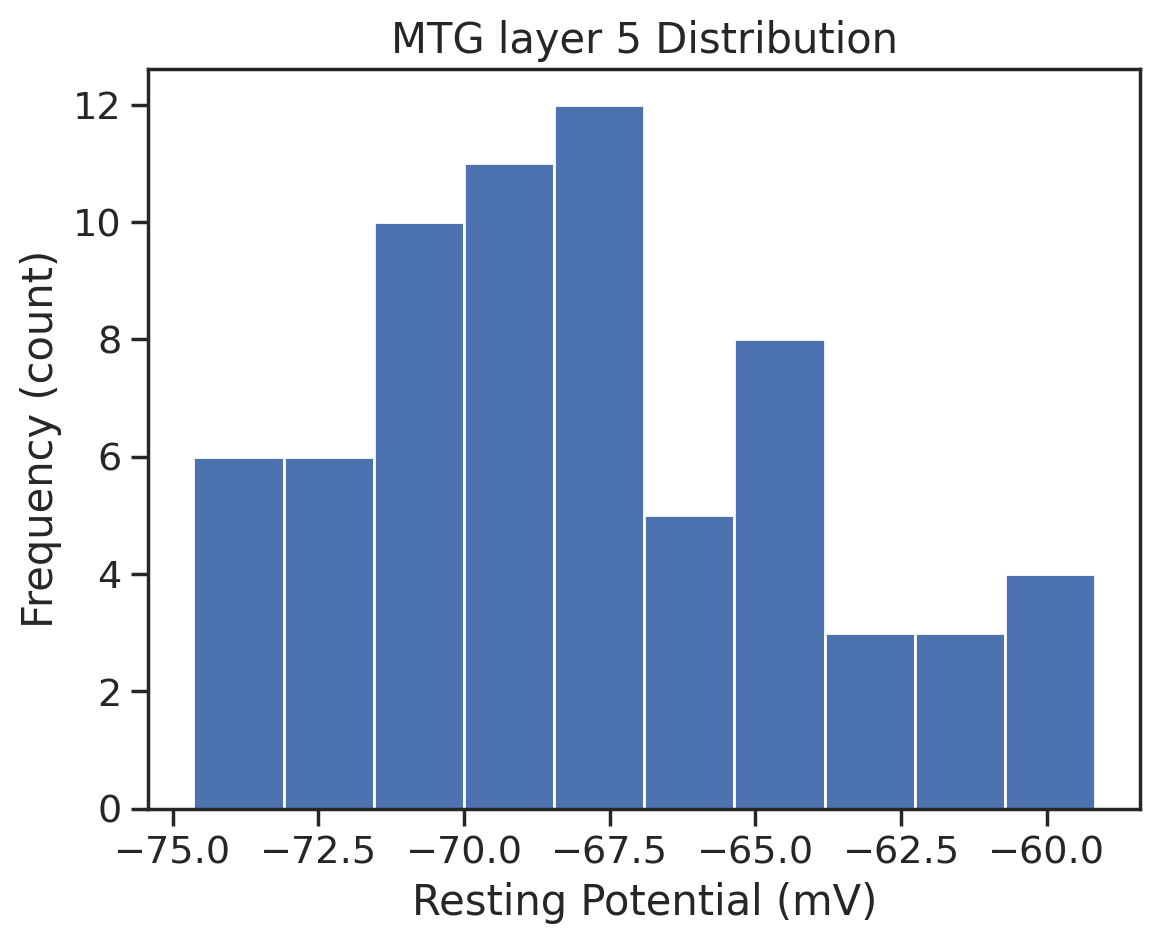

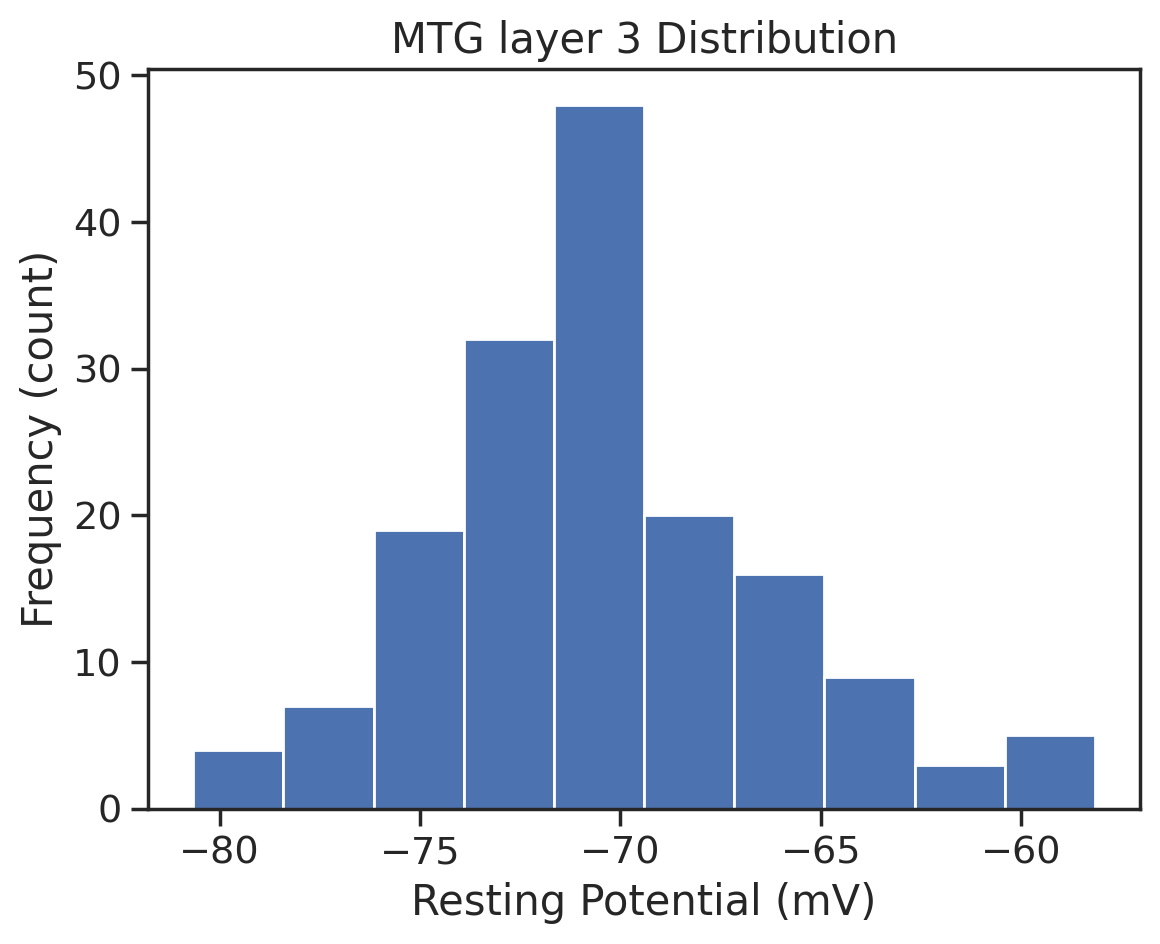

In [ ]:
#@title Cortical Layer Solution
##--- Solution for *Cortical Layer* comparison

# Edit the `sample_5` and `sample_6` assignment statements
sample_5 = mtg_layer5_df['ef__vrest']                               # **EDIT** - name for cortical layer 1 & variable to compare (choose ONE: resting potential OR avg firing rate)
sample_6 = mtg_layer3_df['ef__vrest']                               # **EDIT** - name for cortical layer 2 & variable to compare (choose ONE: resting potential OR avg firing rate)

# Set this text for the plot- easiest to edit here as needed
x_label_name_skew = "Resting Potential (mV)"                        # **EDIT** - variable/column of interest for comparison
y_label_name_skew = "Frequency (count)"                             # y axis label of histogram (don't change)
cl1 = "MTG layer 5"                                                 # **EDIT** - cortical layer 1 (cl1)
cl2 = "MTG layer 3"                                                 # **EDIT** - cortical layer 2 (cl2)
plot_title_skew_cl1 = cl1 + " Distribution"                         # don't change these
plot_title_skew_cl2 = cl2 + " Distribution"


# Don't change below this line ----
# Run the skew test
stats_5, pvalue_5 = stats.skewtest(sample_5)                        # **EDIT** - determine if you need to deal with NaNs, leaving in or removing nan_policy as necessary
stats_6, pvalue_6 = stats.skewtest(sample_6)                        # **EDIT** - determine if you need to deal with NaNs, leaving in or removing nan_policy as necessary

# Print the p-value of both skew tests
print(cl1 + ' skew test pvalue: ' + str(pvalue_5))                  # **EDIT** - make sure you changed the name of the cortical layer name above
print(cl2 + ' skew test pvalue: ' + str(pvalue_6))                  # **EDIT** - make sure you changed the name of the cortical layer name above

# Plot our distributions                                            # don't change these
plt.hist(sample_5)
plt.title(plot_title_skew_cl1)
plt.xlabel(x_label_name_skew)
plt.ylabel(y_label_name_skew)
plt.show()
plt.hist(sample_6)
plt.title(plot_title_skew_cl2)
plt.xlabel(x_label_name_skew)
plt.ylabel(y_label_name_skew)
plt.show()

---
<a name="step3"></a>
## 11.3 Step 3. Run the appropriate statistical test based on the results of the skew test

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>
Copy and paste the code from above that you might need, making sure to <b>edit</b> where you see <code>...</code> as needed for your comparison!<br>
You should only run <b>1 test</b> based on what you found above^!
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

### T-test


Go back above where we ran the [T-test](#ttest)

(In Section 9.0 above: Case Study Question 1: Evaluating brain region 🧠 differences (FroL & MTG) in resting potential)

In [ ]:
##--- EDIT THIS
# Do **not** run both- determine results of skew test above first

# Independent Samples t-test
print(stats.ttest_ind(..., ...))              # **EDIT** make sure to check the sample numbers to match above
                                              # **EDIT** make sure you omit NaNs if needed

### Mann-Whitney U

Go back above where we ran the [Mann-Whitney U](#mann-wu)

(In Section 10.0 above: Case Study Question 2: Evaluating brain region differences (FroL & MTG) 🧠 in average firing rate)

In [ ]:
##--- EDIT THIS
# Do **not** run both- determine results of skew test above first

# Mann-Whitney U test
print(stats.mannwhitneyu(..., ..., ...))      # **EDIT** make sure to check the sample numbers to match above
                                              # **EDIT** make sure you omit NaNs if needed

---
<a name="plot-cortical-layers"></a>
### 11.3.1 Plot for Cortical Layer Comparison Only

In [ ]:
#@title Task for Cortical Layers
from IPython.display import HTML

alert_info = '''
<div class="alert alert-block alert-warning">
<div style= "font-size: 20px">
  <h4 class="alert-heading">Task for Cortical Layers </h4>
<b>Extra step</b>: if you are comparing across cortical layers, you need to create a plot here. <br><br>
If you are comparing brain regions, we already made the plots above, so those can be reviewed for interpretation here.<br>
Two examples are below. Make sure to <b>edit</b> these as you need for your variable of interest, or choose another one and try it out on your own!

</div>
'''


display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

In [ ]:
##--- EDIT THIS - plotting code for *cortical layer* comparison

# This is an example for the swarm plot, but you are welcome to pick any of the ones above that you would like
# Review this to help you adapt those if you decide to try them out!

## Swarm plot - all cortical layers

# Set this text for the plot- easiest to edit here as needed
x_label_name_cl = "Cortical Layers"
y_label_name_cl = "Comparison of Interest"                               # **EDIT** - this depends on comparison y axis
plot_title_cl = "Edit Title of Plot"                                     # **EDIT** - this depends on comparison y axis
fig_name_swarm_cl = "Swarm_CorticalLayer_ComparisonInfoGoesHere.png"     # **EDIT** - this depends on comparison y axis

# Create our plot
c = sns.catplot(
            data = <insert_dataframe_for_corticallayers>,                # **EDIT** - this doesn't depend on layer- the code will plot all layers for you based on the column values :)
            kind = "swarm",
            x = "<insert_column_name_of_cortical_layers>",               # **EDIT** - variable for our x-axis (should be cortical layer)
            y = "<insert_column_name_of_variable>",                      # **EDIT** - depends on what you chose- resting potential or avg firing rate
            hue = "<insert_column_name_of_cortical_layers>",             # **EDIT** - column name for  cortical layer so each is a different color
            palette = "Set2",                                            # set the color palette we want- lots of options!
            size = 2,                                                    # sets the size of the dots
            order = [3,5])                                               # **EDIT** (if you want)- [1,2,3,4,5,6] will show all layers (if in dataframe) or just the 2 you selected

# Adjustment + aesthetics of plot                                        # Don't change below this line ---
c.set_axis_labels(x_label_name_cl, y_label_name_cl, labelpad=10)         # set axis labels
c.figure.set_size_inches(6.5, 4.5)                                       # set figure size
c.ax.margins(.15)                                                        # set margins
plt.title(plot_title_cl, y=1.05)                                         # add a title so we know what we plotted!
#plt.ylim(0,180);                                                        # **Check** - don't change the first time - review the plot and see if you need to adjust

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_swarm_cl), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_swarm_cl}' to: {save_path}")                    # Remind us where and what the file name is

In [ ]:
##--- Edit this- another example of plotting code for *cortical layer* comparison

## Violin + boxplot plot - all cortical layers

# Set this text for the plot- easiest to edit here as needed
x_label_name_cl = "Cortical Layers"
y_label_name_cl = "Average Firing Rate (spikes/s)"                      # **EDIT** - this depends on comparison y axis
plot_title_cl = "Average Firing Rate Across Cortical Layers"            # **EDIT** - this depends on comparison y axis
fig_name_vbp_cl = "Violin_Boxplot_CorticalLayer_AvgFiringRate.png"      # **EDIT** - this depends on comparison y axis

# Create our plot
st = sns.violinplot(                                                    # use seaborn package (sns) and specify type of plot - strip plot
            data = <insert_dataframe_for_corticallayers>,               # **EDIT** - this doesn't depend on layer- the code will plot all layers for you based on the column values :)
            x = "<insert_column_name_of_cortical_layers>",              # **EDIT** - variable for our x-axis (should be cortical layer)
            y = "<insert_column_name_of_variable>",                     # **EDIT** - depends on what you chose- resting potential or avg firing rate
            hue = "<insert_column_name_of_cortical_layers>",            # **EDIT** - column name for  cortical layer so each is a different color
            order = [1,2,3,4,5,6],                                      # **EDIT** (if you want)- can show all layers (if in dataframe) or just the 2 you selected
            palette = "Set2")                                           # set the color palette we want- lots of options!

# Adjustment + aesthetics of plot
st.figure.set_size_inches(6.5, 4.5)                                     # Don't change below this line ---
sns.despine()                                                           # remove top and right axes (w/o this, full box border)
plt.xlabel(x_label_name_cl)                                             # use matplotlib (plt) to adjust the x axis on this one
plt.ylabel(y_label_name_cl)                                             # use matplotlib (plt) to adjust the y axis on this one
plt.title(plot_title_cl, y=1.05)                                        # add a title so we know what we plotted!
#plt.ylim(-5,150);                                                      # **Check** - don't change the first time - review the plot and see if you need to adjust
plt.legend().remove()                                                   # This overpowers the plot if not removed

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_vbp_cl), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_vbp_cl}' to: {save_path}")                     # Remind us where and what the file name is

In [ ]:
#@title Cortical Layer & Resting Potential Solution - All Layers

# This is an example for the violin + boxplot, but you are welcome to pick any of the ones above that you would like
# Review this to help you adapt those if you decide to try them out!

## Violin + boxplot - all cortical layers

# Set this text for the plot- easiest to edit here as needed
x_label_name_cl = "Cortical Layers"
y_label_name_cl = "Resting Potential (mV)"                               # **EDIT** - this depends on comparison y axis
plot_title_cl = "Resting Potential Across Cortical Layers"               # **EDIT** - this depends on comparison y axis
fig_name_vb_cl = "ViolinBoxplot_CorticalLayer_RestingPotential.png"  # **EDIT** - this depends on comparison y axis

# Create our plot
c = sns.violinplot(
            data = mtg_df,                                               # **EDIT** - this doesn't depend on layer- the code will plot all layers for you based on the column values :)
            x = "structure__layer",                                      # **EDIT** - variable for our x-axis (should be cortical layer)
            y = "ef__vrest",                                             # **EDIT** - depends on what you chose- resting potential or avg firing rate
            hue = "structure__layer",                                    # **EDIT** - column name for  cortical layer so each is a different color
            palette = "Set2",                                            # set the color palette we want- lots of options!
            order = [1,2,3,4,5,6])                                       # **EDIT** (if you want)- [1,2,3,4,5,6] will show all layers (if in dataframe) or just the 2 you selected

# Adjustment + aesthetics of plot
st.figure.set_size_inches(6.5, 4.5)                             # Don't change below this line ---
sns.despine()                                                   # remove top and right axes (w/o this, full box border)
plt.xlabel(x_label_name_cl)                                     # use matplotlib (plt) to adjust the x axis on this one
plt.ylabel(y_label_name_cl)                                     # use matplotlib (plt) to adjust the y axis on this one
plt.title(plot_title_cl, y=1.05)                                # add a title so we know what we plotted!
plt.ylim(-90,-50);                                              # **EDIT** - don't change the first time - review the plot and see if you need to adjust
plt.legend().remove()                                           # This overpowers the plot if not removed

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_vb_cl), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_vb_cl}' to: {save_path}")                    # Remind us where and what the file name is

In [ ]:
#@title Cortical Layer & Resting Potential Solution - Layers 3 & 5

# This is an example for the swarm plot, but you are welcome to pick any of the ones above that you would like
# Review this to help you adapt those if you decide to try them out!

## Swarm plot - all cortical layers

# Set this text for the plot- easiest to edit here as needed
x_label_name_cl = "Cortical Layers"
y_label_name_cl = "Resting Potential (mV)"                               # **EDIT** - this depends on comparison y axis
plot_title_cl = "Resting Potential Across Cortical Layers"               # **EDIT** - this depends on comparison y axis
fig_name_swarm_cl = "Swarm_CorticalLayer_RestingPotential.png"           # **EDIT** - this depends on comparison y axis

# Create our plot
c = sns.catplot(
            data = mtg_df,                                               # **EDIT** - this doesn't depend on layer- the code will plot all layers for you based on the column values :)
            kind = "swarm",
            x = "structure__layer",                                      # **EDIT** - variable for our x-axis (should be cortical layer)
            y = "ef__vrest",                                             # **EDIT** - depends on what you chose- resting potential or avg firing rate
            hue = "structure__layer",                                    # **EDIT** - column name for  cortical layer so each is a different color
            palette = "Set2",                                            # set the color palette we want- lots of options!
            size = 5,                                                    # sets the size of the dots
            order = [3,5])                                               # **EDIT** (if you want)- [1,2,3,4,5,6] will show all layers (if in dataframe) or just the 2 you selected

# Adjustment + aesthetics of plot                                        # Don't change below this line ---
c.set_axis_labels(x_label_name_cl, y_label_name_cl, labelpad=10)         # set axis labels
c.figure.set_size_inches(6.5, 4.5)                                       # set figure size
c.ax.margins(.15)                                                        # set margins
plt.title(plot_title_cl, y=1.05)                                         # add a title so we know what we plotted!
#plt.ylim(0,180);                                                        # **Check** - don't change the first time - review the plot and see if you need to adjust
c.legend.remove()

# Save our figure to gdrive
plt.savefig(os.path.join(save_path, fig_name_swarm_cl), dpi=300, bbox_inches='tight')  # adjust the name to include correct plot type and variable being plotted

print(f"Saved '{fig_name_swarm_cl}' to: {save_path}")                    # Remind us where and what the file name is

---
<a name="step4"></a>
## 11.4 Step 4. Interpret your results<br>

In [ ]:
#@title Task
from IPython.display import HTML

alert_info = '''
<div style= "font-size: 20px"; class="alert alert-info" role="alert">
  <h4 class="alert-heading">Task</h4>

What can you say about the difference between neurons in the brain regions or cortical layers? What can't you say? Think about the sample you were testing when you describe what your results apply to.
Use the example text from above and write out your results.
</div>
'''

display(HTML('<link href="https://nbviewer.org/static/build/styles.css" rel="stylesheet">'))
display(HTML(alert_info))

**Make sure to respond to this question in the text cell below!**

<mark>*Type your response here*

^ Refer back to the [**Example of how to interpret/write the results**](#results-interp) section to answer this

---
<a name="wrap-up"></a>
# 12.0 Wrapping Up


Before you finish, make sure to double check you have completed all of the following items for your writeup:


1.   Both plots for FroL & MTG are saved in your google drive (resting potential & avg firing rate- these actually include all brain regions)
     - They will be saved here: MyDrive/**NeuroCodingWorkshop_EpilepsyCaseStudy_Materials**
2.   [1 comparison of your choice](#choice-comp):
     * You ran the appropriate [skew test](#step2) (check for NaNs!)
     * You ran the correct [statistical test](#step3) (independent t-test or Mann Whitney U- but not both!)
     * You responded to [questions](#step4) that asked for your **written** interpretation
3. If you test cortical layers, you [created the 2 dataframes](#new-dataframes-comp) needed to produce your skew and statistical tests
     * You also need to create [1 plot](#plot-cortical-layers) to include in your write-up (can include all layers)
     * Code is similar to the plots we made above, but depends on the brain region and cortical layers you used (goes along with the dataframes you made)





If you're unsure or have questions, please ask us!


# Post-Session Survey 📌

Please fill out the post-session survey (anonymous):

---
<a name="errors"></a>
# Errors and Troubleshooting ❗

If you run into any issues with the dataframes, I've included code here so that you can import the brains dataset and the individual datasets for the 3 brain regions.

In [ ]:
## Import individual brain region files and brains data
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1lQzIDW3vRqZ5le_VXUNygEp7moU3GlD_' -O frol_df.csv
frol_df = pd.read_csv('frol_df.csv')
print('frol_df data imported!')

In [ ]:
## Import individual brain region files and brains data
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=11SdUpeKMP8wuPg7-uKuY2COdX83mH341' -O mtg_df.csv
mtg_df = pd.read_csv('mtg_df.csv')
print('mtg_df data imported!')

In [ ]:
## Import individual brain region files and brains data
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1Fb-xsflKF2xjjIVrz7qSRzyLKsJR93WW' -O mfg_df.csv
mfg_df = pd.read_csv('mfg_df.csv')
print('mfg_df data imported!')

In [ ]:
## Import individual brain region files and brains data
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1E7o5G4GPy82Ht1QhWQ5A85GjrolQYHCi' -O brains.csv
brains = pd.read_csv('brains.csv')
print('brains data imported!')

---
<a name="credits"></a>
# Technical Notes & Credits 👏 🧑

The exercises for this case study were adapted from colleagues. <br>The results from developing this lesson plan for teaching have also been published and are available [online](https://www.funjournal.org/volume-22-issue-1-fall-2023/milligan-et-al-june-221a66-a73/): <br> Milligan, E.C., Casimo, K., Buchanan, L., Hutson, B. & Robertson, S. Mapping Human Neuronal Diversity in the Search for New Therapeutics: Using Real Human Neuron Data to Build Student Quantitative Skills. JUNE, 2023 Spring; 22(1):A66-A73.<br>
Example text and scipy stats info also referenced examples from Teaching and Learning with NWB Datasets, the module on [Data Science in Python: SciPy](https://nwb4edu.github.io/Data_Science_In_Python/SciPy.html).
